# GPDdatabase DVCS data explorer

Inventory and visualization of all DVCS YAML datasets in the local GPDdatabase checkout, plus an explicit user-defined kinematic contract for pseudodata generation. Database values remain in source conventions; this notebook does not harmonize signs, normalizations, or observable definitions across experiments.

In [1]:
from collections import Counter, defaultdict
import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

def find_repository(start=Path.cwd()):
    for path in (start.resolve(), *start.resolve().parents):
        if (path / "pyproject.toml").exists() and (path / "src/extract_dvcs_cff").exists():
            return path
    return Path.cwd().resolve()

REPOSITORY = find_repository()
DATABASE_ROOT = Path(os.environ.get(
    "DVCS_GPDDATABASE_ROOT", REPOSITORY / ".dvcs/database/gpddatabase"
)).expanduser().resolve()
print(f"Database root: {DATABASE_ROOT}")

Database root: /w/hallc-scshelf2102/nps/singhav/extract_dvcs_gpd/.dvcs/database/gpddatabase


In [2]:
KINEMATIC_FIELDS = ("xB", "Q2", "minus_t", "phi_rad", "W", "nu")
KINEMATIC_LABELS = {
    "xB": r"$x_B$", "Q2": r"$Q^2$ [GeV$^2$]",
    "minus_t": r"$-t$ [GeV$^2$]", "phi_rad": r"$\phi$ [rad]",
    "W": r"$W$ [GeV]", "nu": r"$\nu$ [GeV]",
}

def locate_dvcs_data(root):
    candidates = (root / "gpddatabase/data/DVCS", root / "data/DVCS", root)
    for candidate in candidates:
        if candidate.is_dir() and any(candidate.rglob("*.yaml")):
            return candidate
    raise FileNotFoundError(f"No DVCS YAML files below {root}")

def finite(value):
    try:
        number = float(value)
    except (TypeError, ValueError):
        return math.nan
    return number if math.isfinite(number) else math.nan

def component(matrix, row, column):
    try:
        return finite(matrix[row][column])
    except (IndexError, TypeError):
        return math.nan

def normalize_kinematics(names, units, values):
    result = {key: math.nan for key in KINEMATIC_FIELDS}
    for name, unit, raw in zip(names, units, values):
        value = finite(raw)
        if name == "t":
            result["minus_t"] = -value
        elif name == "phi":
            result["phi_rad"] = math.radians(value) if unit == "deg" else value
        elif name in result:
            result[name] = value
    return result

def load_database(root):
    data_dir = locate_dvcs_data(root)
    datasets, kinematics, measurements = [], [], []
    files = sorted(data_dir.rglob("*.yaml"))
    for path in files:
        document = yaml.safe_load(path.read_text(encoding="utf-8"))
        general = document.get("general_info", {})
        conditions = general.get("conditions", {}) or {}
        source = str(path.relative_to(data_dir))
        for dataset_index, wrapper in enumerate(document.get("data", [])):
            dataset = wrapper["data_set"]
            kin, obs = dataset["kinematics"], dataset["observable"]
            names, units, rows = kin["name"], kin["unit"], kin["value"]
            observables, observable_units, values = obs["name"], obs["unit"], obs["value"]
            if len(rows) != len(values):
                raise ValueError(f"{source}: kinematic/observable row mismatch")
            dataset_id = f"{document.get('uuid', source)}:{dataset_index}"
            data_type = str(general.get("data_type", ""))
            pseudodata = bool(general.get("pseudodata", False))
            metadata = {
                "dataset_id": dataset_id, "source": source,
                "collaboration": str(general.get("collaboration", "unknown")),
                "reference": str(general.get("reference", "")),
                "beam_energy_GeV": finite(conditions.get("lepton_beam_energy")),
                "data_type": data_type, "pseudodata": pseudodata,
                "lattice_or_pseudodata": pseudodata or data_type == "LATTICE_QCD",
            }
            datasets.append({**metadata, "rows": len(rows), "observables": tuple(observables)})
            stat, syst, norm = obs.get("stat_unc", []), obs.get("sys_unc", []), obs.get("norm_unc", [])
            for row_index, (kin_row, value_row) in enumerate(zip(rows, values)):
                point = {**metadata, "row_index": row_index, **normalize_kinematics(names, units, kin_row)}
                kinematics.append(point)
                for column, (observable, unit) in enumerate(zip(observables, observable_units)):
                    measurements.append({
                        **point, "observable": observable, "unit": unit,
                        "value": component(values, row_index, column),
                        "stat_unc": component(stat, row_index, column),
                        "sys_unc": component(syst, row_index, column),
                        "norm_unc": finite(norm[column]) if column < len(norm) else math.nan,
                    })
    return data_dir, files, datasets, kinematics, measurements

In [3]:
DATA_DIR, SOURCE_FILES, DATASETS, KINEMATICS, MEASUREMENTS = load_database(DATABASE_ROOT)
observable_counts = Counter(row["observable"] for row in MEASUREMENTS)
collaboration_counts = Counter(row["collaboration"] for row in DATASETS)

print(f"{len(SOURCE_FILES):,} YAML files | {len(DATASETS):,} datasets | "
      f"{len(KINEMATICS):,} kinematic rows | {len(MEASUREMENTS):,} measurements")
print(f"{len(observable_counts):,} observables | {len(collaboration_counts):,} collaborations")
auxiliary_count = sum(row["lattice_or_pseudodata"] for row in MEASUREMENTS)
print(f"Lattice/pseudodata measurements: {auxiliary_count:,}; experimental measurements: {len(MEASUREMENTS) - auxiliary_count:,}")
print("Collaborations:", ", ".join(f"{name} ({count})" for name, count in collaboration_counts.most_common()))

33 YAML files | 56 datasets | 23,372 kinematic rows | 27,570 measurements
35 observables | 7 collaborations
Lattice/pseudodata measurements: 10,521; experimental measurements: 17,049
Collaborations: HERMES (22), CLAS (11), HallA (10), H1 (7), COMPASS (2), NONE (2), ZEUS (2)


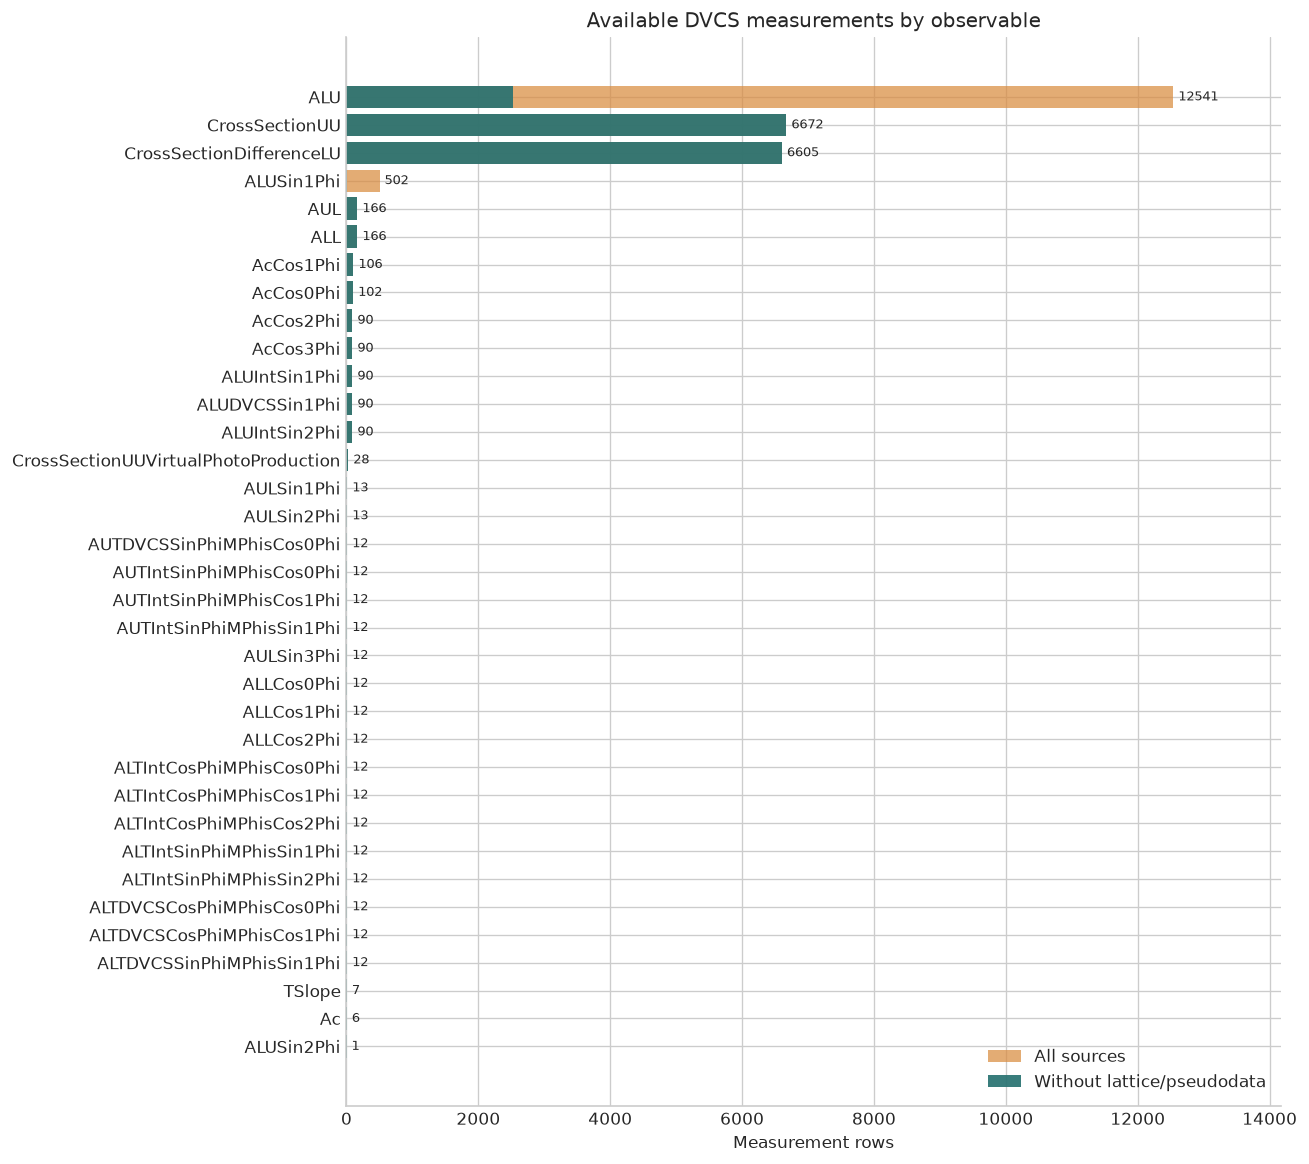

In [4]:
experimental_counts = Counter(row["observable"] for row in MEASUREMENTS if not row["lattice_or_pseudodata"])
ordered = observable_counts.most_common()[::-1]
names, counts = zip(*ordered)
experimental = [experimental_counts[name] for name in names]
fig, ax = plt.subplots(figsize=(11, max(6, 0.28 * len(names))))
bars = ax.barh(names, counts, color="#d98c3f", alpha=0.72, label="All sources")
ax.barh(names, experimental, color="#287271", alpha=0.92, label="Without lattice/pseudodata")
ax.bar_label(bars, fmt="%d", padding=3, fontsize=8)
ax.set(xlabel="Measurement rows", title="Available DVCS measurements by observable")
ax.set_xlim(0, max(counts) * 1.13)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

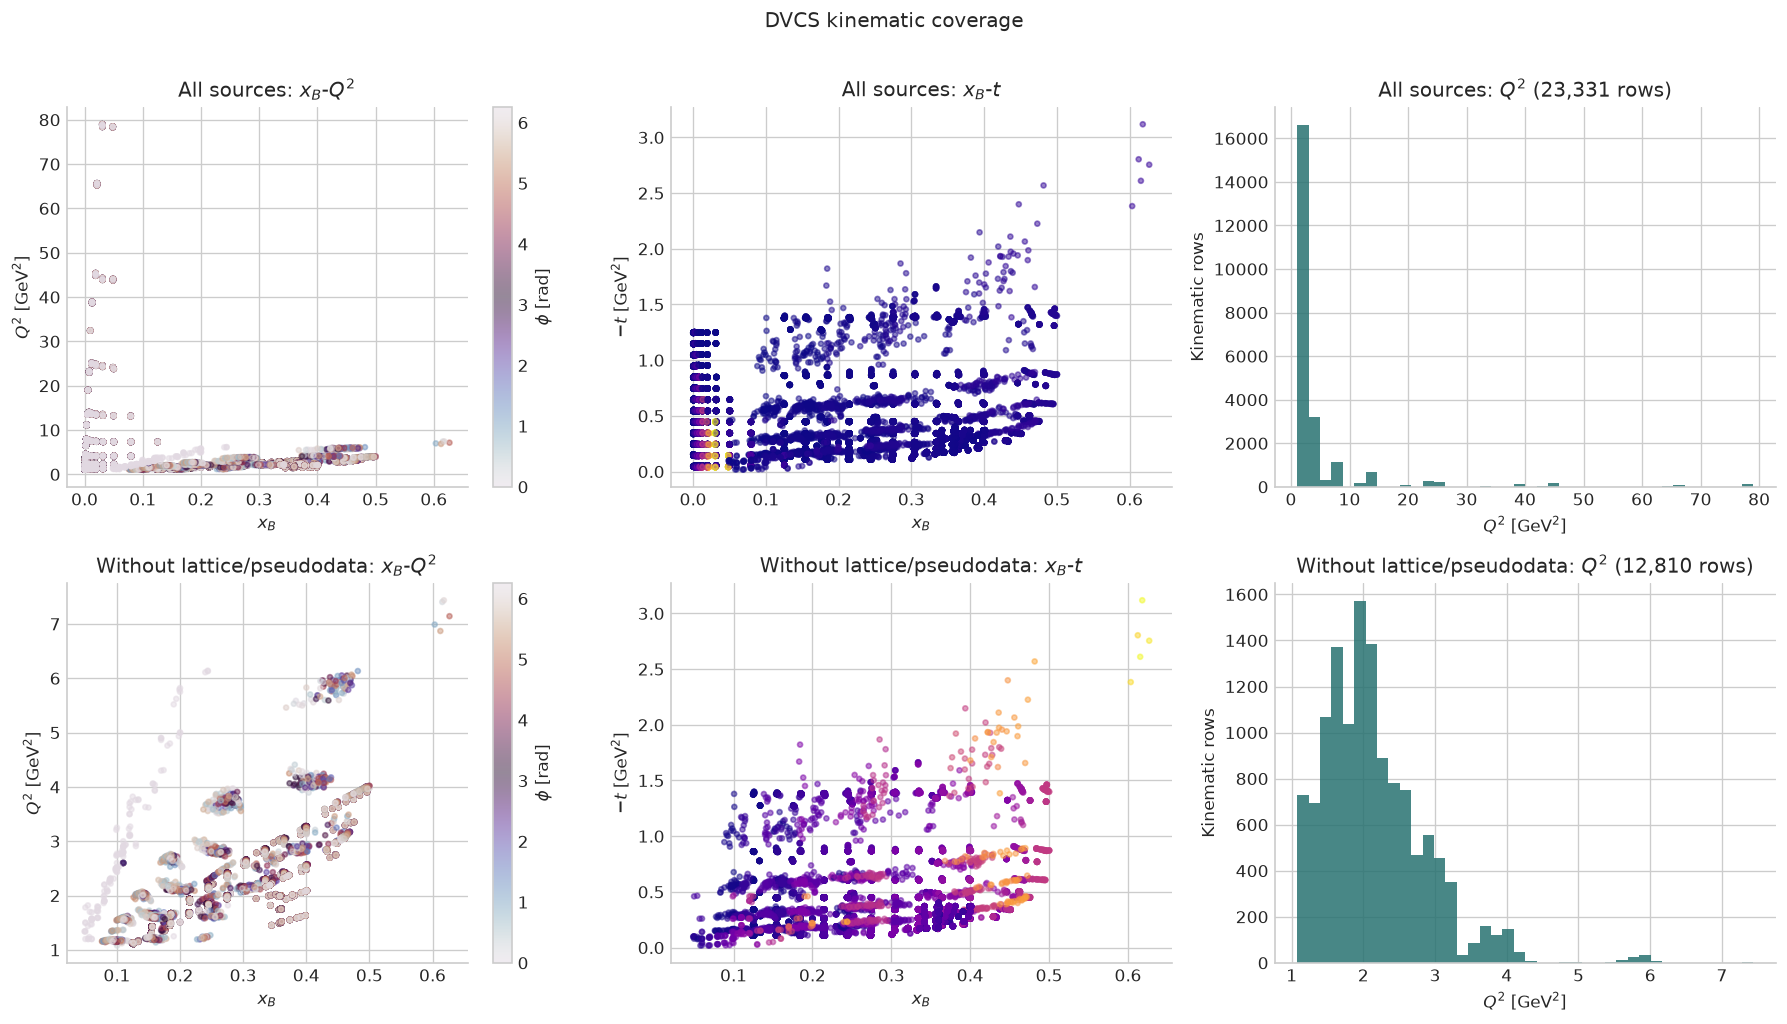

In [5]:
coverage_views = (
    ("All sources", KINEMATICS),
    ("Without lattice/pseudodata", [row for row in KINEMATICS if not row["lattice_or_pseudodata"]]),
)
fig, axes = plt.subplots(2, 3, figsize=(15, 8.4))
for axis_row, (view_name, records) in zip(axes, coverage_views):
    complete = [row for row in records if all(math.isfinite(row[key]) for key in ("xB", "Q2", "minus_t"))]
    step = max(1, len(complete) // 12000)
    sample = complete[::step]
    x_b = np.array([row["xB"] for row in sample])
    q2 = np.array([row["Q2"] for row in sample])
    minus_t = np.array([row["minus_t"] for row in sample])
    phi = np.array([row["phi_rad"] for row in sample])
    color = np.where(np.isfinite(phi), np.mod(phi, 2 * np.pi), 0.0)
    scatter = axis_row[0].scatter(x_b, q2, c=color, s=9, alpha=0.5, cmap="twilight", rasterized=True)
    axis_row[0].set(xlabel=KINEMATIC_LABELS["xB"], ylabel=KINEMATIC_LABELS["Q2"], title=f"{view_name}: $x_B$-$Q^2$")
    fig.colorbar(scatter, ax=axis_row[0], label=KINEMATIC_LABELS["phi_rad"])
    axis_row[1].scatter(x_b, minus_t, c=q2, s=9, alpha=0.5, cmap="plasma", rasterized=True)
    axis_row[1].set(xlabel=KINEMATIC_LABELS["xB"], ylabel=KINEMATIC_LABELS["minus_t"], title=f"{view_name}: $x_B$-$t$")
    axis_row[2].hist(q2[np.isfinite(q2)], bins=40, color="#287271", alpha=0.85)
    axis_row[2].set(xlabel=KINEMATIC_LABELS["Q2"], ylabel="Kinematic rows", title=f"{view_name}: $Q^2$ ({len(complete):,} rows)")
fig.suptitle("DVCS kinematic coverage", y=1.01)
plt.tight_layout()
plt.show()

Experimental display envelope: x_B=(0.1, 0.6), Q2=(1.1, 4.5) GeV^2, -t=(0.1, 1.5) GeV^2
Bjorken-limit xi range: [0.053, 0.429]
Unique experimental four-tuples shown: 3,029 (no lattice/pseudodata)
Experimental core/edge labels: Counter({'core': 2686, 'edge/stress': 343})
Displayed beam energies (15): 3.355, 4.25, 4.45, 4.455, 4.8, 5.55, 5.7, 5.75, 5.7572, 5.77, 5.88, 5.932, 10.2, 10.6, 27.6 GeV
Metadata energies without complete tuples in this envelope: (27.5, 160.0)
Boundary checks: -t_min(0.5, 1.1)=0.280, -t_min(0.5, 4.0)=0.379 GeV^2; W(0.5, 1.1)=1.407 GeV; y(0.1, 4.0, 10.6)=2.011
BMK finite-Q^2 kinematics: https://arxiv.org/abs/hep-ph/0112108
Physical unique-anchor pool: 2,897 (core=2,554, edge/stress=343)
Selected four-tuple strata: Counter({'anchor core': 179, 'anchor edge/stress': 39, 'Sobol core': 38})
Unique groups: 256; phi-expanded sites: 2,048
Selected energy counts: {np.float64(3.355): 1, np.float64(4.25): 2, np.float64(4.45): 2, np.float64(4.455): 6, np.float64(4.8): 5, np.

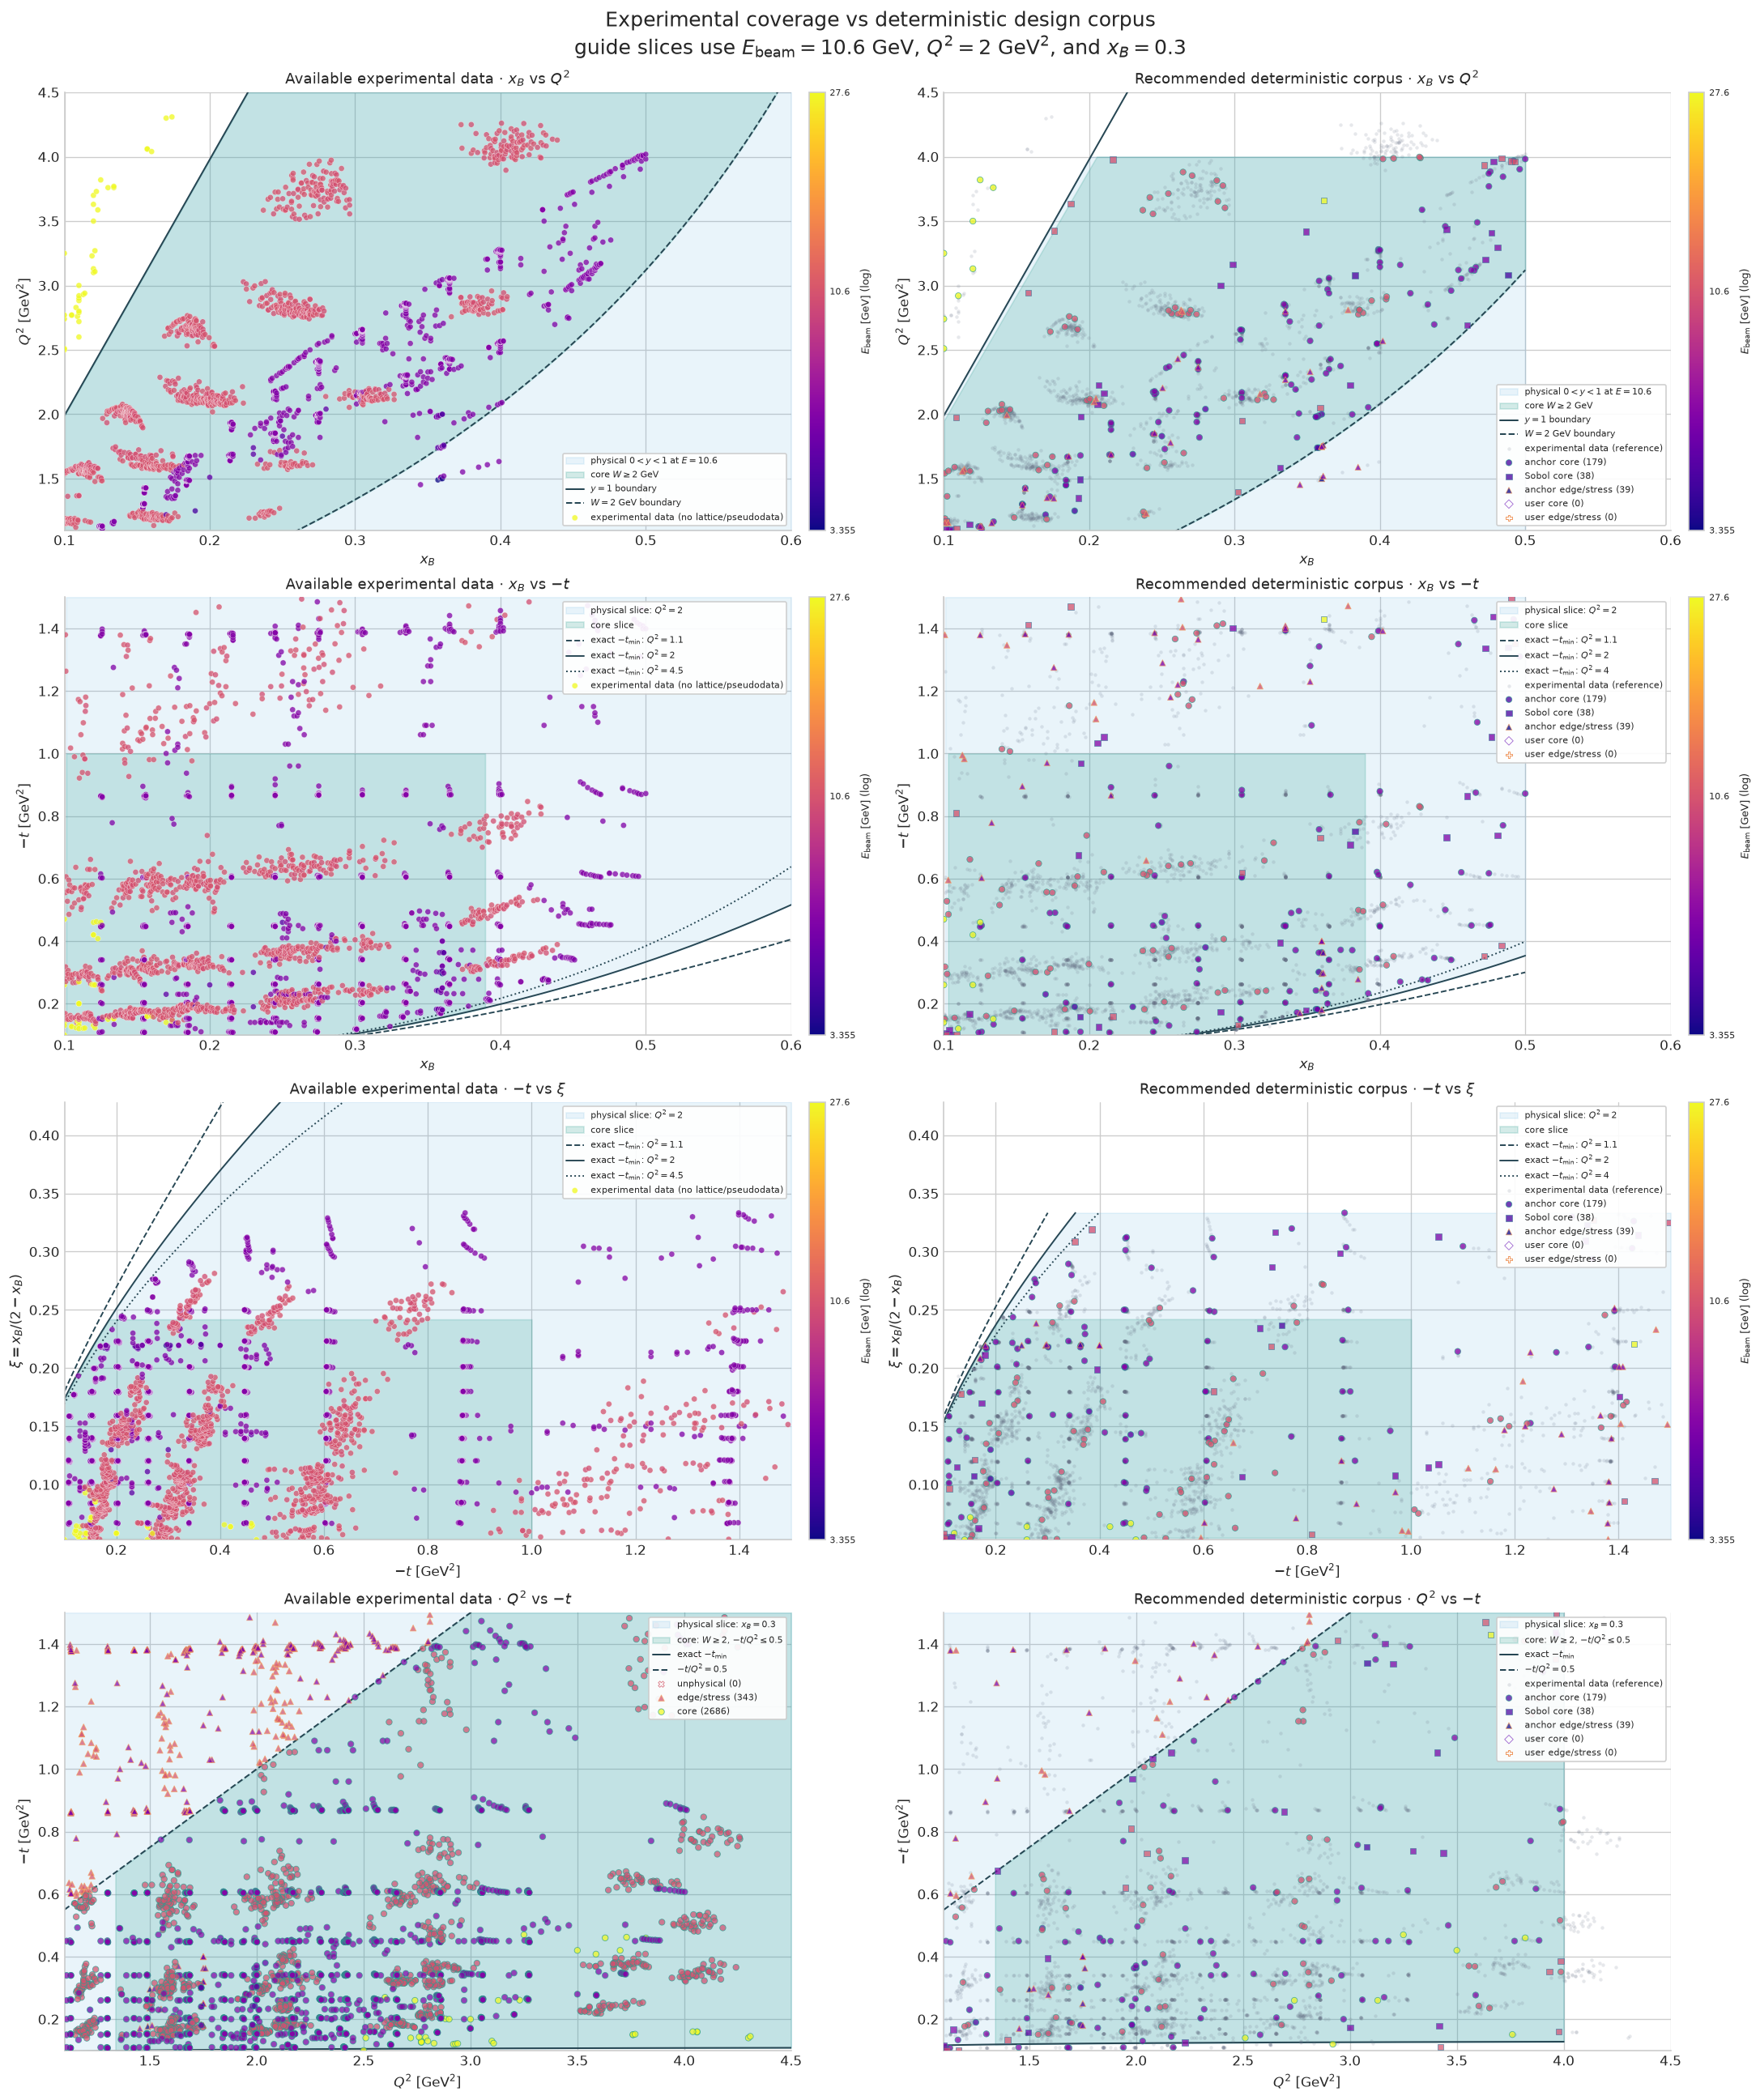

In [6]:
# EXPERIMENTAL COVERAGE AND DETERMINISTIC PSEUDODATA CORPUS DESIGN.
# Experimental display settings and reference physics labels.
# Comparison policy: use only measurements without lattice/pseudodata for now.
COMPARISON_KINEMATICS = [row for row in KINEMATICS if not row["lattice_or_pseudodata"]]
BEAM_ENERGY_DECIMALS = 6
BEAM_ENERGIES_GEV = tuple(sorted({
    round(float(row["beam_energy_GeV"]), BEAM_ENERGY_DECIMALS)
    for row in COMPARISON_KINEMATICS if math.isfinite(row["beam_energy_GeV"])
}))

# Experimental comparison envelope.
XB_RANGE = (0.10, 0.60)
Q2_RANGE_GEV2 = (1.10, 4.50)
MINUS_T_RANGE_GEV2 = (0.10, 1.50)
TMIN_MARGIN_GEV2 = 0.00        # Set > 0 to stay away from the exact boundary.
CORE_W_MIN_GEV = 2.0
CORE_MAX_MINUS_T_OVER_Q2 = 0.50
DISPLAY_BEAM_ENERGY_GEV = 10.60 if 10.60 in BEAM_ENERGIES_GEV else BEAM_ENERGIES_GEV[-1]
DISPLAY_Q2_GEV2 = 2.00
PROTON_MASS_GEV = 0.938272013

def exact_minus_t_min(x_b, Q2_GeV2):
    """Exact finite-Q^2 BMK boundary, Eq. (31), returned as positive -t_min."""
    x_b = np.asarray(x_b, dtype=float)
    Q2_GeV2 = np.asarray(Q2_GeV2, dtype=float)
    epsilon2 = 4.0 * PROTON_MASS_GEV**2 * x_b**2 / Q2_GeV2
    numerator = 2.0 * (1.0 - x_b) * (1.0 - np.sqrt(1.0 + epsilon2)) + epsilon2
    denominator = 4.0 * x_b * (1.0 - x_b) + epsilon2
    return Q2_GeV2 * numerator / denominator

def exact_minus_t_max(x_b, Q2_GeV2):
    """Exact finite-Q^2 backward limit, returned as positive maximum -t."""
    x_b = np.asarray(x_b, dtype=float)
    Q2_GeV2 = np.asarray(Q2_GeV2, dtype=float)
    epsilon2 = 4.0 * PROTON_MASS_GEV**2 * x_b**2 / Q2_GeV2
    numerator = 2.0 * (1.0 - x_b) * (1.0 + np.sqrt(1.0 + epsilon2)) + epsilon2
    denominator = 4.0 * x_b * (1.0 - x_b) + epsilon2
    return Q2_GeV2 * numerator / denominator

def derived_kinematics(x_b, Q2_GeV2, minus_t_GeV2, beam_energy_GeV):
    """Return the quantities used to validate and stratify one candidate tuple."""
    xi = x_b / (2.0 - x_b)  # Common Bjorken-limit mapping; x_B is not GPD x.
    y = Q2_GeV2 / (2.0 * PROTON_MASS_GEV * beam_energy_GeV * x_b)
    W_GeV = np.sqrt(PROTON_MASS_GEV**2 + Q2_GeV2 * (1.0 - x_b) / x_b)
    minus_t_min_GeV2 = float(exact_minus_t_min(x_b, Q2_GeV2))
    return {
        "xi": xi, "y": y, "W_GeV": W_GeV,
        "minus_t_min_GeV2": minus_t_min_GeV2,
        "minus_t_max_GeV2": float(exact_minus_t_max(x_b, Q2_GeV2)),
        "minus_t_over_Q2": minus_t_GeV2 / Q2_GeV2,
    }

def classify_kinematics(x_b, Q2_GeV2, minus_t_GeV2, beam_energy_GeV):
    """Label a tuple as outside, unphysical, core, or edge/stress."""
    values = derived_kinematics(x_b, Q2_GeV2, minus_t_GeV2, beam_energy_GeV)
    inside = (XB_RANGE[0] <= x_b <= XB_RANGE[1]
              and Q2_RANGE_GEV2[0] <= Q2_GeV2 <= Q2_RANGE_GEV2[1]
              and MINUS_T_RANGE_GEV2[0] <= minus_t_GeV2 <= MINUS_T_RANGE_GEV2[1]
              and beam_energy_GeV in BEAM_ENERGIES_GEV)
    if not inside:
        return "outside master envelope", values
    physical = (0.0 < values["y"] < 1.0
                and minus_t_GeV2 >= values["minus_t_min_GeV2"] + TMIN_MARGIN_GEV2
                and minus_t_GeV2 <= values["minus_t_max_GeV2"])
    if not physical:
        return "unphysical", values
    core = (values["W_GeV"] >= CORE_W_MIN_GEV
            and values["minus_t_over_Q2"] <= CORE_MAX_MINUS_T_OVER_Q2)
    return ("core" if core else "edge/stress"), values

if not (0.0 < XB_RANGE[0] < XB_RANGE[1] < 1.0):
    raise ValueError("XB_RANGE must be strictly ordered inside (0, 1)")
if not (0.0 < Q2_RANGE_GEV2[0] < Q2_RANGE_GEV2[1]):
    raise ValueError("Q2_RANGE_GEV2 must be positive and strictly ordered")
if not (0.0 < MINUS_T_RANGE_GEV2[0] < MINUS_T_RANGE_GEV2[1]):
    raise ValueError("MINUS_T_RANGE_GEV2 must be positive and strictly ordered")
if not BEAM_ENERGIES_GEV or any(energy <= 0.0 for energy in BEAM_ENERGIES_GEV):
    raise ValueError("BEAM_ENERGIES_GEV must contain positive values")
if DISPLAY_BEAM_ENERGY_GEV not in BEAM_ENERGIES_GEV:
    raise ValueError("DISPLAY_BEAM_ENERGY_GEV must be one of BEAM_ENERGIES_GEV")
if not Q2_RANGE_GEV2[0] <= DISPLAY_Q2_GEV2 <= Q2_RANGE_GEV2[1]:
    raise ValueError("DISPLAY_Q2_GEV2 must lie inside Q2_RANGE_GEV2")

# Unique experimental four-tuples avoid counting repeated phi bins as extra coverage.
experimental_tuples = sorted({
    (float(row["xB"]), float(row["Q2"]), float(row["minus_t"]),
     round(float(row["beam_energy_GeV"]), BEAM_ENERGY_DECIMALS))
    for row in COMPARISON_KINEMATICS
    if all(math.isfinite(row[key])
           for key in ("xB", "Q2", "minus_t", "beam_energy_GeV"))
})
available_experimental_points = np.asarray([
    point for point in experimental_tuples
    if XB_RANGE[0] <= point[0] <= XB_RANGE[1]
    and Q2_RANGE_GEV2[0] <= point[1] <= Q2_RANGE_GEV2[1]
    and MINUS_T_RANGE_GEV2[0] <= point[2] <= MINUS_T_RANGE_GEV2[1]
    and point[3] > 0.0
], dtype=float).reshape(-1, 4)
if not len(available_experimental_points):
    raise ValueError("No complete experimental tuples lie inside the display envelope")
available_experimental_labels = np.asarray([
    classify_kinematics(*point)[0] for point in available_experimental_points
], dtype=object)
displayed_experimental_energies = tuple(sorted(set(available_experimental_points[:, 3])))
energies_without_displayed_points = tuple(sorted(
    set(BEAM_ENERGIES_GEV) - set(displayed_experimental_energies)
))

from matplotlib.colors import LogNorm

DB_COLOR = "#667085"
ALLOWED_COLOR = "#4ea8de"
CORE_COLOR = "#2a9d8f"
EDGE_COLOR = "#f4a261"
INVALID_COLOR = "#d1495b"
BOUNDARY_COLOR = "#264653"
ENERGY_CMAP = "plasma"

xi_bounds = tuple(value / (2.0 - value) for value in XB_RANGE)
print(f"Experimental display envelope: x_B={XB_RANGE}, Q2={Q2_RANGE_GEV2} GeV^2, "
      f"-t={MINUS_T_RANGE_GEV2} GeV^2")
print(f"Bjorken-limit xi range: [{xi_bounds[0]:.3f}, {xi_bounds[1]:.3f}]")
print(f"Unique experimental four-tuples shown: {len(available_experimental_points):,} "
      "(no lattice/pseudodata)")
print("Experimental core/edge labels:", Counter(available_experimental_labels))
print(f"Displayed beam energies ({len(displayed_experimental_energies)}): "
      + ", ".join(f"{energy:g}" for energy in displayed_experimental_energies) + " GeV")
print("Metadata energies without complete tuples in this envelope:",
      energies_without_displayed_points or "none")
print("Boundary checks: "
      f"-t_min(0.5, 1.1)={exact_minus_t_min(0.5, 1.1):.3f}, "
      f"-t_min(0.5, 4.0)={exact_minus_t_min(0.5, 4.0):.3f} GeV^2; "
      f"W(0.5, 1.1)={derived_kinematics(0.5, 1.1, 0.5, DISPLAY_BEAM_ENERGY_GEV)['W_GeV']:.3f} GeV; "
      f"y(0.1, 4.0, {DISPLAY_BEAM_ENERGY_GEV:g})="
      f"{derived_kinematics(0.1, 4.0, 0.5, DISPLAY_BEAM_ENERGY_GEV)['y']:.3f}")
print("BMK finite-Q^2 kinematics: https://arxiv.org/abs/hep-ph/0112108")

# The recommended deterministic design is evaluated in this same cell so the
# two point sets and their physics domains are produced atomically.
# RECOMMENDED LARGE-CORPUS DESIGN: unique maximin anchors plus conditional Sobol fill.
# Both designs now share one matched visualization below.
from scipy.stats import qmc

DESIGN_GROUP_COUNT = 256
# Optional exact override: rows are (x_B, Q2, -t, E_beam, phi).
# Leave as None to use the deterministic design below. No empirical box is imposed.
USER_DEFINED_KINEMATIC_SITES = None
DESIGN_ALLOCATION_FRACTIONS = {
    "experimental_anchor_core": 0.70,
    "conditional_sobol_core": 0.15,
    "experimental_anchor_edge_stress": 0.15,
}


def _largest_remainder_allocation(total, fractions):
    """Convert stratum fractions to deterministic integer counts summing to total."""
    if not isinstance(total, int) or total <= 0:
        raise ValueError("DESIGN_GROUP_COUNT must be a positive integer")
    if not math.isclose(sum(fractions.values()), 1.0, rel_tol=0.0, abs_tol=1e-12):
        raise ValueError("DESIGN_ALLOCATION_FRACTIONS must sum to one")
    raw = {label: total * fraction for label, fraction in fractions.items()}
    counts = {label: math.floor(value) for label, value in raw.items()}
    remainder = total - sum(counts.values())
    order = sorted(
        fractions, key=lambda label: (raw[label] - counts[label], label), reverse=True
    )
    for label in order[:remainder]:
        counts[label] += 1
    return counts


DESIGN_ALLOCATION = _largest_remainder_allocation(
    DESIGN_GROUP_COUNT, DESIGN_ALLOCATION_FRACTIONS
)
STRATIFIED_SAMPLING_SETTINGS = {
    "schema_version": 1,
    "group_count": DESIGN_GROUP_COUNT,
    "random_seed": 20260901,
    "envelope": {
        "x_b": (0.10, 0.50),
        "Q2_GeV2": (1.10, 4.00),
        "minus_t_GeV2": (0.10, 1.50),
    },
    "allocation_fractions": DESIGN_ALLOCATION_FRACTIONS,
    "allocation": DESIGN_ALLOCATION,
    "physics": {
        "tmin_margin_GeV2": 0.02,
        "core_y_margin": 0.02,
        "core_W_min_GeV": 2.0,
        "core_max_minus_t_over_Q2": 0.50,
    },
    "energy_quota": "sqrt(unique_anchor_count), minimum one per supported energy",
    "distance_coordinates": (
        "linear_x_b", "log_Q2", "conditional_u_t", "log_beam_energy"
    ),
    "phi": {"mode": "balanced_mid-bin_grid", "count_per_group": 8},
}
_SD = STRATIFIED_SAMPLING_SETTINGS
_XB, _Q2, _MT = (_SD["envelope"][key] for key in (
    "x_b", "Q2_GeV2", "minus_t_GeV2"
))
_PHYSICS, _ALLOC, _SEED = _SD["physics"], _SD["allocation"], _SD["random_seed"]


def _design_metrics(point):
    return derived_kinematics(*map(float, point))


def _design_class(point):
    x_b, q2, minus_t, energy = map(float, point)
    values = _design_metrics(point)
    inside = (
        _XB[0] <= x_b <= _XB[1]
        and _Q2[0] <= q2 <= _Q2[1]
        and _MT[0] <= minus_t <= _MT[1]
        and energy > 0.0
    )
    physical = (
        inside
        and 0.0 < values["y"] < 1.0
        and minus_t
        >= values["minus_t_min_GeV2"] + _PHYSICS["tmin_margin_GeV2"]
        and minus_t <= values["minus_t_max_GeV2"]
    )
    margin = _PHYSICS["core_y_margin"]
    core = (
        physical
        and margin <= values["y"] <= 1.0 - margin
        and values["W_GeV"] >= _PHYSICS["core_W_min_GeV"]
        and values["minus_t_over_Q2"]
        <= _PHYSICS["core_max_minus_t_over_Q2"]
    )
    return "core" if core else "edge/stress" if physical else "unphysical"


# Only unique experimental kinematic tuples are retained. No measurement value
# or uncertainty enters this pool or any subsequent selection.
_design_anchor_pool = sorted({
    tuple(map(float, point))
    for point in experimental_tuples
    if _design_class(point) != "unphysical"
})
_design_core_pool = [
    point for point in _design_anchor_pool if _design_class(point) == "core"
]
_design_edge_pool = [
    point for point in _design_anchor_pool
    if _design_class(point) == "edge/stress"
]


def _raw_design_features(points):
    rows = []
    for x_b, q2, minus_t, energy in points:
        lower = max(
            _MT[0],
            float(exact_minus_t_min(x_b, q2))
            + _PHYSICS["tmin_margin_GeV2"],
        )
        u_t = (minus_t - lower) / max(
            _MT[1] - lower, np.finfo(float).eps
        )
        rows.append((x_b, math.log(q2), u_t, math.log(energy)))
    return np.asarray(rows, dtype=np.float64)


_feature_reference = _raw_design_features(_design_anchor_pool)
_feature_low, _feature_high = np.quantile(
    _feature_reference, (0.01, 0.99), axis=0
)
_feature_scale = np.where(
    _feature_high > _feature_low, _feature_high - _feature_low, 1.0
)


def _design_features(points):
    return np.clip(
        (_raw_design_features(points) - _feature_low) / _feature_scale,
        0.0, 1.0,
    )


def _energy_quotas(counts, total, capacities=None):
    energies = tuple(sorted(counts))
    if total < len(energies):
        raise ValueError("allocation is smaller than the supported energy count")
    weights = {energy: math.sqrt(counts[energy]) for energy in energies}
    norm = sum(weights.values())
    targets = {energy: total * weights[energy] / norm for energy in energies}
    quotas = {energy: 1 for energy in energies}
    while sum(quotas.values()) < total:
        eligible = [
            energy for energy in energies
            if capacities is None or quotas[energy] < capacities[energy]
        ]
        if not eligible:
            raise ValueError("allocation exceeds unique-anchor capacity")
        selected = max(
            eligible, key=lambda energy: (targets[energy] - quotas[energy], -energy)
        )
        quotas[selected] += 1
    return quotas


def _maximin(points, count, seed):
    ordered = sorted(set(points))
    if count > len(ordered):
        raise ValueError("maximin request exceeds unique candidates")
    if count == len(ordered):
        return ordered
    features = _design_features(ordered)
    current = int(np.random.default_rng(seed).integers(len(ordered)))
    available = np.ones(len(ordered), dtype=bool)
    minimum_distance2 = np.full(len(ordered), np.inf)
    chosen = []
    for _ in range(count):
        chosen.append(current)
        available[current] = False
        delta = features - features[current]
        minimum_distance2 = np.minimum(
            minimum_distance2, np.einsum("ij,ij->i", delta, delta)
        )
        minimum_distance2[~available] = -np.inf
        if len(chosen) < count:
            current = int(np.flatnonzero(np.isclose(
                minimum_distance2, minimum_distance2.max(),
                rtol=0.0, atol=1e-15,
            ))[0])
    return [ordered[index] for index in chosen]


def _select_anchor_stratum(points, count, seed):
    counts = Counter(point[3] for point in points)
    quotas = _energy_quotas(counts, count, capacities=counts)
    selected = []
    for rank, energy in enumerate(sorted(quotas)):
        candidates = [point for point in points if point[3] == energy]
        selected.extend(_maximin(
            candidates, quotas[energy], seed + 1009 * (rank + 1)
        ))
    return selected, quotas


def _sobol_core_candidates(energy, seed, power=13):
    unit_points = qmc.Sobol(
        d=3, scramble=True, seed=seed
    ).random_base2(power)
    candidates = []
    for u_x, u_q2, u_t in unit_points:
        x_b = _XB[0] + (_XB[1] - _XB[0]) * u_x
        q2_lower = max(
            _Q2[0],
            (_PHYSICS["core_W_min_GeV"]**2 - PROTON_MASS_GEV**2)
            * x_b / (1.0 - x_b),
        )
        q2_upper = min(
            _Q2[1],
            2.0 * PROTON_MASS_GEV * energy * x_b
            * (1.0 - _PHYSICS["core_y_margin"]),
        )
        if q2_lower >= q2_upper:
            continue
        q2 = math.exp(
            math.log(q2_lower)
            + u_q2 * (math.log(q2_upper) - math.log(q2_lower))
        )
        minus_t_lower = max(
            _MT[0],
            float(exact_minus_t_min(x_b, q2))
            + _PHYSICS["tmin_margin_GeV2"],
        )
        minus_t_upper = min(
            _MT[1], _PHYSICS["core_max_minus_t_over_Q2"] * q2,
            float(exact_minus_t_max(x_b, q2)),
        )
        if minus_t_lower >= minus_t_upper:
            continue
        point = (
            x_b, q2,
            minus_t_lower + u_t * (minus_t_upper - minus_t_lower),
            float(energy),
        )
        if _design_class(point) == "core":
            candidates.append(point)
    return candidates


_anchor_core, _anchor_core_quotas = _select_anchor_stratum(
    _design_core_pool, _ALLOC["experimental_anchor_core"], _SEED
)
_anchor_edge, _anchor_edge_quotas = _select_anchor_stratum(
    _design_edge_pool, _ALLOC["experimental_anchor_edge_stress"], _SEED + 1
)
_core_energy_counts = Counter(point[3] for point in _design_core_pool)
_sobol_quotas = _energy_quotas(
    _core_energy_counts, _ALLOC["conditional_sobol_core"]
)
_sobol_core = []
for rank, energy in enumerate(sorted(_sobol_quotas)):
    candidates = _sobol_core_candidates(
        energy, _SEED + 7919 * (rank + 1)
    )
    quota = _sobol_quotas[energy]
    if len(candidates) < quota:
        raise RuntimeError(
            f"only {len(candidates)} Sobol candidates at E={energy:g}; "
            f"need {quota}"
        )
    _sobol_core.extend(_maximin(
        candidates, quota, _SEED + 104729 * (rank + 1)
    ))

_design_records = (
    [(point, "anchor core") for point in _anchor_core]
    + [(point, "Sobol core") for point in _sobol_core]
    + [(point, "anchor edge/stress") for point in _anchor_edge]
)
_DESIGN_PHI_RAD = (
    np.arange(_SD["phi"]["count_per_group"]) + 0.5
) * (2.0 * math.pi / _SD["phi"]["count_per_group"])
if USER_DEFINED_KINEMATIC_SITES is None:
    STRATIFIED_PARTONS_KINEMATIC_POINTS = np.asarray(
        [point for point, _ in _design_records], dtype=np.float64
    )
    STRATIFIED_PARTONS_LABELS = np.asarray(
        [label for _, label in _design_records], dtype=object
    )
    STRATIFIED_PARTONS_KINEMATIC_SITES = np.asarray([
        (*point, phi)
        for point in STRATIFIED_PARTONS_KINEMATIC_POINTS
        for phi in _DESIGN_PHI_RAD
    ], dtype=np.float64)
    DESIGN_SOURCE_LABEL = "Recommended deterministic corpus"
else:
    user_sites = np.asarray(USER_DEFINED_KINEMATIC_SITES, dtype=np.float64)
    if user_sites.ndim != 2 or user_sites.shape[1] != 5 or not len(user_sites):
        raise ValueError("USER_DEFINED_KINEMATIC_SITES must be a nonempty N x 5 array")
    user_errors = []
    for index, (x_b, q2, minus_t, energy, phi) in enumerate(user_sites):
        reasons = []
        if not np.isfinite((x_b, q2, minus_t, energy, phi)).all():
            reasons.append("all values must be finite")
        elif not 0.0 < x_b < 1.0:
            reasons.append("x_B must lie in (0,1)")
        elif q2 < 1.0:
            reasons.append("Q2 must be at least native Q0^2=1 GeV^2")
        elif energy <= 0.0:
            reasons.append("beam energy must be positive")
        elif not 0.0 <= phi <= 2.0 * math.pi:
            reasons.append("phi must lie in [0,2pi]")
        else:
            values = derived_kinematics(x_b, q2, minus_t, energy)
            if not 0.0 < values["y"] < 1.0:
                reasons.append(f"y={values['y']:.6g} must lie in (0,1)")
            if not values["minus_t_min_GeV2"] <= minus_t <= values["minus_t_max_GeV2"]:
                reasons.append("-t is outside exact finite-Q2 DVCS limits")
        if reasons:
            user_errors.append(f"site {index}: " + "; ".join(reasons))
    if user_errors:
        print("USER-DEFINED KINEMATICS INVALID:")
        for message in user_errors[:20]:
            print("  " + message)
        raise ValueError(f"{len(user_errors)} user-defined kinematic site(s) violate physics")
    unique_points = list(dict.fromkeys(tuple(row[:4]) for row in user_sites))
    STRATIFIED_PARTONS_KINEMATIC_POINTS = np.asarray(unique_points, dtype=np.float64)
    user_labels = []
    for point in STRATIFIED_PARTONS_KINEMATIC_POINTS:
        values = derived_kinematics(*point)
        core = (
            _PHYSICS["core_y_margin"] <= values["y"] <= 1.0 - _PHYSICS["core_y_margin"]
            and values["W_GeV"] >= _PHYSICS["core_W_min_GeV"]
            and values["minus_t_over_Q2"] <= _PHYSICS["core_max_minus_t_over_Q2"]
        )
        user_labels.append("user core" if core else "user edge/stress")
    STRATIFIED_PARTONS_LABELS = np.asarray(user_labels, dtype=object)
    STRATIFIED_PARTONS_KINEMATIC_SITES = user_sites.copy()
    _DESIGN_PHI_RAD = np.unique(user_sites[:, 4])
    DESIGN_SOURCE_LABEL = "User-defined kinematic sites"
STRATIFIED_PARTONS_SITE_COLUMNS = (
    "x_b", "Q2_GeV2", "minus_t_GeV2", "beam_energy_GeV", "phi_rad"
)

if USER_DEFINED_KINEMATIC_SITES is None:
    assert len(STRATIFIED_PARTONS_KINEMATIC_POINTS) == _SD["group_count"]
assert len({
    tuple(np.round(point, 12))
    for point in STRATIFIED_PARTONS_KINEMATIC_POINTS
}) == len(STRATIFIED_PARTONS_KINEMATIC_POINTS)
if USER_DEFINED_KINEMATIC_SITES is None:
    for point, label in _design_records:
        expected = "edge/stress" if label == "anchor edge/stress" else "core"
        assert _design_class(point) == expected

print(
    f"Physical unique-anchor pool: {len(_design_anchor_pool):,} "
    f"(core={len(_design_core_pool):,}, "
    f"edge/stress={len(_design_edge_pool):,})"
)
print("Selected four-tuple strata:", Counter(STRATIFIED_PARTONS_LABELS))
print(
    f"Unique groups: {len(STRATIFIED_PARTONS_KINEMATIC_POINTS):,}; "
    f"phi-expanded sites: {len(STRATIFIED_PARTONS_KINEMATIC_SITES):,}"
)
print(
    "Selected energy counts:",
    dict(sorted(Counter(
        STRATIFIED_PARTONS_KINEMATIC_POINTS[:, 3]
    ).items())),
)

_design_styles = {
    "anchor core": ("#2a9d8f", "o"),
    "Sobol core": ("#457b9d", "s"),
    "anchor edge/stress": ("#f4a261", "^"),
    "user core": ("#7b2cbf", "D"),
    "user edge/stress": ("#e85d04", "P"),
}
# MATCHED EXPERIMENTAL-VS-DESIGN COMPARISON
# Columns are sampling designs; rows use identical variables and axis limits.
COMPARISON_DISPLAY_ENERGY_GEV = DISPLAY_BEAM_ENERGY_GEV
COMPARISON_DISPLAY_Q2_GEV2 = DISPLAY_Q2_GEV2
COMPARISON_DISPLAY_XB = 0.30

comparison_specs = (
    {
        "name": "Available experimental data",
        "points": available_experimental_points,
        "point_labels": available_experimental_labels,
        "background": available_experimental_points,
        "show_background": False,
        "envelope": {"x_b": XB_RANGE, "Q2": Q2_RANGE_GEV2,
                     "minus_t": MINUS_T_RANGE_GEV2},
        "physics": {"t_margin": TMIN_MARGIN_GEV2, "y_margin": 0.0,
                    "W_min": CORE_W_MIN_GEV,
                    "max_t_over_Q2": CORE_MAX_MINUS_T_OVER_Q2},
    },
    {
        "name": DESIGN_SOURCE_LABEL,
        "points": STRATIFIED_PARTONS_KINEMATIC_POINTS,
        "point_labels": STRATIFIED_PARTONS_LABELS,
        "background": available_experimental_points,
        "show_background": True,
        "envelope": {"x_b": _XB, "Q2": _Q2, "minus_t": _MT},
        "physics": {"t_margin": _PHYSICS["tmin_margin_GeV2"],
                    "y_margin": _PHYSICS["core_y_margin"],
                    "W_min": _PHYSICS["core_W_min_GeV"],
                    "max_t_over_Q2": _PHYSICS["core_max_minus_t_over_Q2"]},
    },
)

comparison_xb_limits = (
    min(spec["envelope"]["x_b"][0] for spec in comparison_specs),
    max(spec["envelope"]["x_b"][1] for spec in comparison_specs),
)
comparison_q2_limits = (
    min(spec["envelope"]["Q2"][0] for spec in comparison_specs),
    max(spec["envelope"]["Q2"][1] for spec in comparison_specs),
)
comparison_t_limits = (
    min(spec["envelope"]["minus_t"][0] for spec in comparison_specs),
    max(spec["envelope"]["minus_t"][1] for spec in comparison_specs),
)
comparison_xi_limits = tuple(
    value / (2.0 - value) for value in comparison_xb_limits
)
comparison_energies = np.concatenate([
    spec["points"][:, 3] for spec in comparison_specs
])
comparison_energy_norm = LogNorm(vmin=float(comparison_energies.min()),
                                 vmax=float(comparison_energies.max()))
comparison_energy_ticks = tuple(sorted({
    float(comparison_energies.min()), COMPARISON_DISPLAY_ENERGY_GEV,
    float(comparison_energies.max()),
}))

def _comparison_xy(points, row):
    if row == 0:
        return points[:, 0], points[:, 1]
    if row == 1:
        return points[:, 0], points[:, 2]
    if row == 2:
        return points[:, 2], points[:, 0] / (2.0 - points[:, 0])
    return points[:, 1], points[:, 2]

def _add_comparison_energy_bar(fig, axis):
    mappable = plt.cm.ScalarMappable(norm=comparison_energy_norm,
                                      cmap=plt.get_cmap(ENERGY_CMAP))
    mappable.set_array([])
    bar = fig.colorbar(mappable, ax=axis, pad=0.01, fraction=0.043, aspect=28)
    bar.set_label(r"$E_{\rm beam}$ [GeV] (log)", fontsize=7.5)
    bar.set_ticks(comparison_energy_ticks)
    bar.set_ticklabels([f"{energy:g}" for energy in comparison_energy_ticks])
    bar.ax.tick_params(labelsize=6.5)
    bar.ax.minorticks_off()
    return bar

def _add_physics_space(axis, row, spec):
    envelope, physics = spec["envelope"], spec["physics"]
    xb_range, q2_range = envelope["x_b"], envelope["Q2"]
    t_range = envelope["minus_t"]
    t_margin, y_margin = physics["t_margin"], physics["y_margin"]
    W_min, ratio_max = physics["W_min"], physics["max_t_over_Q2"]
    if row == 0:
        x = np.linspace(*xb_range, 400)
        y_upper = np.minimum(q2_range[1],
                             2.0 * PROTON_MASS_GEV * COMPARISON_DISPLAY_ENERGY_GEV * x)
        core_upper = np.minimum(q2_range[1],
                                2.0 * PROTON_MASS_GEV * COMPARISON_DISPLAY_ENERGY_GEV
                                * x * (1.0 - y_margin))
        W_boundary = (W_min**2 - PROTON_MASS_GEV**2) * x / (1.0 - x)
        core_lower = np.maximum(q2_range[0], W_boundary)
        if y_margin > 0.0:
            core_lower = np.maximum(
                core_lower, 2.0 * PROTON_MASS_GEV
                * COMPARISON_DISPLAY_ENERGY_GEV * x * y_margin
            )
        axis.fill_between(x, q2_range[0], y_upper,
                          where=y_upper >= q2_range[0], color=ALLOWED_COLOR,
                          alpha=0.12, label=fr"physical $0<y<1$ at $E={COMPARISON_DISPLAY_ENERGY_GEV:g}$")
        axis.fill_between(x, core_lower, core_upper,
                          where=core_upper >= core_lower, color=CORE_COLOR,
                          alpha=0.20, label=fr"core $W\geq{W_min:g}$ GeV")
        axis.plot(x, 2.0 * PROTON_MASS_GEV * COMPARISON_DISPLAY_ENERGY_GEV * x,
                  "-", color=BOUNDARY_COLOR, lw=1.2, label=r"$y=1$ boundary")
        axis.plot(x, W_boundary, "--", color=BOUNDARY_COLOR, lw=1.2,
                  label=fr"$W={W_min:g}$ GeV boundary")
        return
    if row in (1, 2):
        x = np.linspace(*xb_range, 400)
        xi = x / (2.0 - x)
        t_lower = np.maximum(t_range[0], exact_minus_t_min(
            x, COMPARISON_DISPLAY_Q2_GEV2) + t_margin)
        y_value = (COMPARISON_DISPLAY_Q2_GEV2
                   / (2.0 * PROTON_MASS_GEV * COMPARISON_DISPLAY_ENERGY_GEV * x))
        W_value = np.sqrt(PROTON_MASS_GEV**2 + COMPARISON_DISPLAY_Q2_GEV2
                          * (1.0 - x) / x)
        physical = (y_value > 0.0) & (y_value < 1.0)
        core = (physical & (y_value >= y_margin) & (y_value <= 1.0 - y_margin)
                & (W_value >= W_min))
        core_upper = min(t_range[1], ratio_max * COMPARISON_DISPLAY_Q2_GEV2)
        if row == 1:
            axis.fill_between(x, t_lower, t_range[1],
                              where=physical & (t_lower <= t_range[1]),
                              color=ALLOWED_COLOR, alpha=0.12,
                              label=fr"physical slice: $Q^2={COMPARISON_DISPLAY_Q2_GEV2:g}$")
            axis.fill_between(x, t_lower, core_upper,
                              where=core & (t_lower <= core_upper),
                              color=CORE_COLOR, alpha=0.20, label="core slice")
        else:
            axis.fill_betweenx(xi, t_lower, t_range[1],
                               where=physical & (t_lower <= t_range[1]),
                               color=ALLOWED_COLOR, alpha=0.12,
                               label=fr"physical slice: $Q^2={COMPARISON_DISPLAY_Q2_GEV2:g}$")
            axis.fill_betweenx(xi, t_lower, core_upper,
                               where=core & (t_lower <= core_upper),
                               color=CORE_COLOR, alpha=0.20, label="core slice")
        for q2, style in ((q2_range[0], "--"),
                          (COMPARISON_DISPLAY_Q2_GEV2, "-"),
                          (q2_range[1], ":")):
            tmin = exact_minus_t_min(x, q2) + t_margin
            axis.plot(tmin if row == 2 else x, xi if row == 2 else tmin,
                      style, color=BOUNDARY_COLOR, lw=1.15,
                      label=fr"exact $-t_{{\min}}$: $Q^2={q2:g}$")
        return
    q2 = np.linspace(*q2_range, 400)
    t_lower = np.maximum(t_range[0], exact_minus_t_min(
        COMPARISON_DISPLAY_XB, q2) + t_margin)
    y_value = q2 / (2.0 * PROTON_MASS_GEV
                    * COMPARISON_DISPLAY_ENERGY_GEV * COMPARISON_DISPLAY_XB)
    W_value = np.sqrt(PROTON_MASS_GEV**2 + q2
                      * (1.0 - COMPARISON_DISPLAY_XB) / COMPARISON_DISPLAY_XB)
    physical = (y_value > 0.0) & (y_value < 1.0)
    core = (physical & (y_value >= y_margin) & (y_value <= 1.0 - y_margin)
            & (W_value >= W_min))
    core_upper = np.minimum(t_range[1], ratio_max * q2)
    axis.fill_between(q2, t_lower, t_range[1],
                      where=physical & (t_lower <= t_range[1]),
                      color=ALLOWED_COLOR, alpha=0.12,
                      label=fr"physical slice: $x_B={COMPARISON_DISPLAY_XB:g}$")
    axis.fill_between(q2, t_lower, core_upper,
                      where=core & (t_lower <= core_upper),
                      color=CORE_COLOR, alpha=0.20,
                      label=fr"core: $W\geq{W_min:g}$, $-t/Q^2\leq{ratio_max:g}$")
    axis.plot(q2, exact_minus_t_min(COMPARISON_DISPLAY_XB, q2) + t_margin,
              "-", color=BOUNDARY_COLOR, lw=1.2, label=r"exact $-t_{\min}$")
    axis.plot(q2, ratio_max * q2, "--", color=BOUNDARY_COLOR, lw=1.2,
              label=fr"$-t/Q^2={ratio_max:g}$")

comparison_fig, comparison_axes = plt.subplots(
    4, 2, figsize=(18.0, 21.5), constrained_layout=True
)
row_names = (r"$x_B$ vs $Q^2$", r"$x_B$ vs $-t$",
             r"$-t$ vs $\xi$", r"$Q^2$ vs $-t$")
for column, spec in enumerate(comparison_specs):
    for row in range(4):
        axis = comparison_axes[row, column]
        _add_physics_space(axis, row, spec)
        if spec["show_background"]:
            background_x, background_y = _comparison_xy(spec["background"], row)
            axis.scatter(background_x, background_y, s=7, color=DB_COLOR, alpha=0.16,
                         linewidths=0, rasterized=True, zorder=2,
                         label="experimental data (reference)")
        point_x, point_y = _comparison_xy(spec["points"], row)
        if column == 0 and row < 3:
            axis.scatter(point_x, point_y, c=spec["points"][:, 3],
                         cmap=ENERGY_CMAP, norm=comparison_energy_norm, marker="o",
                         s=18, alpha=0.76, edgecolors="white", linewidths=0.22,
                         rasterized=True, zorder=4,
                         label="experimental data (no lattice/pseudodata)")
        elif column == 1 and row < 3:
            for label, (outline, marker) in _design_styles.items():
                mask = spec["point_labels"] == label
                axis.scatter(point_x[mask], point_y[mask],
                             c=spec["points"][mask, 3], cmap=ENERGY_CMAP,
                             norm=comparison_energy_norm, marker=marker, s=20,
                             alpha=0.76, edgecolors=outline, linewidths=0.48,
                             rasterized=True, zorder=4,
                             label=f"{label} ({int(mask.sum())})")
        elif column == 0:
            user_classes = (("unphysical", INVALID_COLOR, "X"),
                            ("edge/stress", EDGE_COLOR, "^"),
                            ("core", CORE_COLOR, "o"))
            for label, outline, marker in user_classes:
                mask = spec["point_labels"] == label
                axis.scatter(point_x[mask], point_y[mask],
                             c=spec["points"][mask, 3], cmap=ENERGY_CMAP,
                             norm=comparison_energy_norm, marker=marker, s=20,
                             alpha=0.72, edgecolors=outline, linewidths=0.52,
                             rasterized=True, zorder=4,
                             label=f"{label} ({int(mask.sum())})")
        else:
            for label, (outline, marker) in _design_styles.items():
                mask = spec["point_labels"] == label
                axis.scatter(point_x[mask], point_y[mask],
                             c=spec["points"][mask, 3], cmap=ENERGY_CMAP,
                             norm=comparison_energy_norm, marker=marker, s=20,
                             alpha=0.72, edgecolors=outline, linewidths=0.52,
                             rasterized=True, zorder=4,
                             label=f"{label} ({int(mask.sum())})")
        axis.set_title(f"{spec['name']} · {row_names[row]}", fontsize=11)
        axis.legend(fontsize=6.5, frameon=True, framealpha=0.92,
                    loc="upper right" if row != 0 else "lower right")
        if row < 3:
            _add_comparison_energy_bar(comparison_fig, axis)

for axis in comparison_axes[0]:
    axis.set(xlim=comparison_xb_limits, ylim=comparison_q2_limits,
             xlabel=r"$x_B$", ylabel=r"$Q^2$ [GeV$^2$]")
for axis in comparison_axes[1]:
    axis.set(xlim=comparison_xb_limits, ylim=comparison_t_limits,
             xlabel=r"$x_B$", ylabel=r"$-t$ [GeV$^2$]")
for axis in comparison_axes[2]:
    axis.set(xlim=comparison_t_limits, ylim=comparison_xi_limits,
             xlabel=r"$-t$ [GeV$^2$]",
             ylabel=r"$\xi=x_B/(2-x_B)$")
for axis in comparison_axes[3]:
    axis.set(xlim=comparison_q2_limits, ylim=comparison_t_limits,
             xlabel=r"$Q^2$ [GeV$^2$]", ylabel=r"$-t$ [GeV$^2$]")
comparison_fig.suptitle(
    "Experimental coverage vs deterministic design corpus\n"
    + fr"guide slices use $E_{{\rm beam}}={COMPARISON_DISPLAY_ENERGY_GEV:g}$ GeV, "
      fr"$Q^2={COMPARISON_DISPLAY_Q2_GEV2:g}$ GeV$^2$, and $x_B={COMPARISON_DISPLAY_XB:g}$",
    fontsize=15,
)
plt.show()


In [ ]:
# EXPORT THE DETERMINISTIC DESIGN TO A FRAMEWORK experiment.json.
# This cell is preview-only until both a target path is chosen and writing is enabled.
import copy
from datetime import datetime, timezone
import json
import os
import shutil
import tempfile

# Example: REPOSITORY / "workspace/my_project/experiment.json"
EXPERIMENT_JSON_PATH = "/w/hallc-scshelf2102/nps/singhav/extract_dvcs_gpd/workspace/my_extension_2/experiment.json"
WRITE_EXPERIMENT_JSON = True
ALLOW_EXISTING_RESULTS = False

workspace_root = Path(os.environ.get(
    "DVCS_WORKSPACE_ROOT",
    os.environ.get("DVCS_WORKSPACE", REPOSITORY / "workspace"),
)).expanduser()
experiment_candidates = sorted(workspace_root.glob("*/experiment.json"))

EXPORT_KINEMATIC_KEYS = (
    "x_b", "t_GeV2", "phi_rad", "Q2_GeV2", "beam_energy_GeV"
)
NATIVE_Q0_SQUARED_GEV2 = 1.0


def _framework_export_points(sites):
    """Convert (x_B,Q2,-t,E,phi) rows to the public experiment schema."""
    return [
        {
            "x_b": float(x_b),
            "t_GeV2": -float(minus_t),
            "phi_rad": float(phi),
            "Q2_GeV2": float(q2),
            "beam_energy_GeV": float(energy),
        }
        for x_b, q2, minus_t, energy, phi in np.asarray(sites, dtype=float)
    ]


def _point_violations(point):
    reasons = []
    if any(not math.isfinite(point[key]) for key in EXPORT_KINEMATIC_KEYS):
        return ["all kinematic values must be finite"]
    if not 0.0 < point["x_b"] < 1.0:
        reasons.append("x_b outside physical interval (0,1)")
    if point["Q2_GeV2"] < NATIVE_Q0_SQUARED_GEV2:
        reasons.append("Q2 below native input scale Q0^2=1 GeV^2")
    if point["beam_energy_GeV"] <= 0.0:
        reasons.append("beam energy must be positive")
    if not 0.0 <= point["phi_rad"] <= 2.0 * math.pi:
        reasons.append("phi_rad outside [0,2pi]")
    if reasons:
        return reasons
    y_value = (point["Q2_GeV2"]
               / (2.0 * PROTON_MASS_GEV * point["beam_energy_GeV"] * point["x_b"]))
    if not 0.0 < y_value < 1.0:
        reasons.append("fixed-target y outside (0,1)")
    minus_t = -point["t_GeV2"]
    required_t = float(exact_minus_t_min(point["x_b"], point["Q2_GeV2"]))
    if minus_t < required_t:
        reasons.append("below exact forward -t limit")
    maximum_t = float(exact_minus_t_max(point["x_b"], point["Q2_GeV2"]))
    if minus_t > maximum_t:
        reasons.append("above exact backward -t limit")
    return reasons


def _resolve_experiment_path(value):
    if value is None:
        return None
    candidate = Path(value).expanduser()
    if not candidate.is_absolute():
        candidate = REPOSITORY / candidate
    candidate = candidate.resolve(strict=True)
    if candidate.name != "experiment.json":
        raise ValueError("EXPERIMENT_JSON_PATH must name an existing experiment.json")
    return candidate


def _load_export_target(path):
    document = json.loads(path.read_text(encoding="utf-8"))
    if not isinstance(document, dict):
        raise ValueError("experiment.json must contain one JSON object")
    if document.get("schema_version") not in {7, 8, 9}:
        raise ValueError("the exporter supports public experiment schemas 7, 8, and 9")
    if document.get("experiment", {}).get("name") != path.parent.name:
        raise ValueError("experiment.name must match the project directory name")
    synthetic = document.get("synthetic_dataset")
    if not isinstance(synthetic, dict) or "kinematics" not in synthetic:
        raise ValueError("experiment.json has no synthetic_dataset.kinematics array")
    return document


def _atomic_json_update(path, document):
    """Back up the current contract, then atomically replace it with valid JSON."""
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
    backup = path.with_name(f"experiment.backup-{stamp}.json")
    shutil.copy2(path, backup)
    descriptor, temporary_name = tempfile.mkstemp(
        prefix=".experiment.", suffix=".tmp", dir=path.parent
    )
    try:
        with os.fdopen(descriptor, "w", encoding="utf-8") as stream:
            json.dump(document, stream, indent=4, allow_nan=False)
            stream.write("\n")
            stream.flush()
            os.fsync(stream.fileno())
        os.chmod(temporary_name, path.stat().st_mode)
        os.replace(temporary_name, path)
    except Exception:
        if os.path.exists(temporary_name):
            os.unlink(temporary_name)
        raise
    return backup


export_points = _framework_export_points(STRATIFIED_PARTONS_KINEMATIC_SITES)
group_index_by_point = {
    tuple(point): index
    for index, point in enumerate(STRATIFIED_PARTONS_KINEMATIC_POINTS)
}
site_group_indices = [
    group_index_by_point[tuple(site[:4])]
    for site in STRATIFIED_PARTONS_KINEMATIC_SITES
]
violation_counts = Counter()
invalid_site_indices = []
for site_index, point in enumerate(export_points):
    reasons = _point_violations(point)
    if reasons:
        invalid_site_indices.append(site_index)
        violation_counts.update(reasons)

invalid_group_indices = sorted({site_group_indices[index] for index in invalid_site_indices})
print(f"Export payload: {len(STRATIFIED_PARTONS_KINEMATIC_POINTS):,} groups, "
      f"{len(export_points):,} exact kinematic sites, "
      f"{len(_DESIGN_PHI_RAD):,} unique phi values")
if violation_counts:
    print(f"Framework compatibility: BLOCKED ({len(invalid_site_indices):,} sites in "
          f"{len(invalid_group_indices):,} groups)")
    for reason, count in sorted(violation_counts.items()):
        print(f"  {count:,}: {reason}")
    for group_index in invalid_group_indices[:5]:
        x_b, q2, minus_t, energy = STRATIFIED_PARTONS_KINEMATIC_POINTS[group_index]
        print(f"  example group {group_index}: x_B={x_b:.5g}, Q2={q2:.5g}, "
              f"-t={minus_t:.5g}, E={energy:.5g}")
else:
    print("Framework compatibility: PASS")

target_path = _resolve_experiment_path(EXPERIMENT_JSON_PATH)
target_document = _load_export_target(target_path) if target_path else None
candidate_document = None
contract_errors = []
if target_document is not None:
    candidate_document = copy.deepcopy(target_document)
    candidate_document["synthetic_dataset"]["kinematics"] = export_points
    candidate_document["synthetic_dataset"]["kinematics_source"] = {"mode": "manual"}
    if candidate_document["schema_version"] == 9:
        design_training = candidate_document["inference"]["observation_design_training"]
        active_counts = design_training["active_kinematic_counts"]
        if design_training["enabled"] and (
            not active_counts or active_counts[-1] != len(export_points)
        ):
            contract_errors.append(
                "enabled observation-design training must include the new full site count "
                f"{len(export_points):,} in active_kinematic_counts"
            )
    print(f"Target: {target_path}")
    print(f"Existing kinematic sites: "
          f"{len(target_document['synthetic_dataset']['kinematics']):,}")
else:
    print("Set EXPERIMENT_JSON_PATH to one of these projects before enabling writes:")
    for candidate in experiment_candidates:
        print(f"  {candidate}")

if WRITE_EXPERIMENT_JSON:
    if target_path is None:
        raise ValueError("set EXPERIMENT_JSON_PATH before WRITE_EXPERIMENT_JSON=True")
    if violation_counts:
        raise ValueError(
            "sampled sites violate the current framework contract; do not export a partial design"
        )
    if contract_errors:
        raise ValueError("; ".join(contract_errors))
    results_root = target_path.parent / "results"
    existing_result = (
        next((item for item in results_root.rglob("*") if item.is_file()), None)
        if results_root.is_dir() else None
    )
    if existing_result is not None and not ALLOW_EXISTING_RESULTS:
        raise RuntimeError(
            "project already contains results; use a fresh project or explicitly set "
            "ALLOW_EXISTING_RESULTS=True after reviewing the result-contract consequences"
        )
    backup_path = _atomic_json_update(target_path, candidate_document)
    round_trip = json.loads(target_path.read_text(encoding="utf-8"))
    if round_trip != candidate_document:
        raise RuntimeError(f"round-trip verification failed; restore {backup_path}")
    print(f"WROTE {len(export_points):,} sites to {target_path}")
    print(f"Backup: {backup_path}")
    print(f"Next validation: cd {REPOSITORY} && ./dvcs show {target_path.parent.name}")
else:
    print("Preview only: experiment.json was not modified (WRITE_EXPERIMENT_JSON=False).")


Export payload: 256 groups, 2,048 exact kinematic sites, 8 unique phi values
Framework compatibility: PASS
Target: /w/hallc-scshelf2102/nps/singhav/extract_dvcs_gpd/workspace/my_extension_2/experiment.json
Existing kinematic sites: 6
WROTE 2,048 sites to /w/hallc-scshelf2102/nps/singhav/extract_dvcs_gpd/workspace/my_extension_2/experiment.json
Backup: /w/hallc-scshelf2102/nps/singhav/extract_dvcs_gpd/workspace/my_extension_2/experiment.backup-20260902T202411323241Z.json
Next validation: cd /w/hallc-scshelf2102/nps/singhav/extract_dvcs_gpd && ./dvcs show my_extension_2


## Inspect one observable

Set `OBSERVABLE` to any name from the inventory plot. `X_AXIS = "auto"` prefers azimuth, then momentum transfer, $x_B$, and $Q^2$. Pointwise error bars are $\sqrt{\sigma_\mathrm{stat}^2+\sigma_\mathrm{sys}^2}$; correlated normalization uncertainties are intentionally excluded.

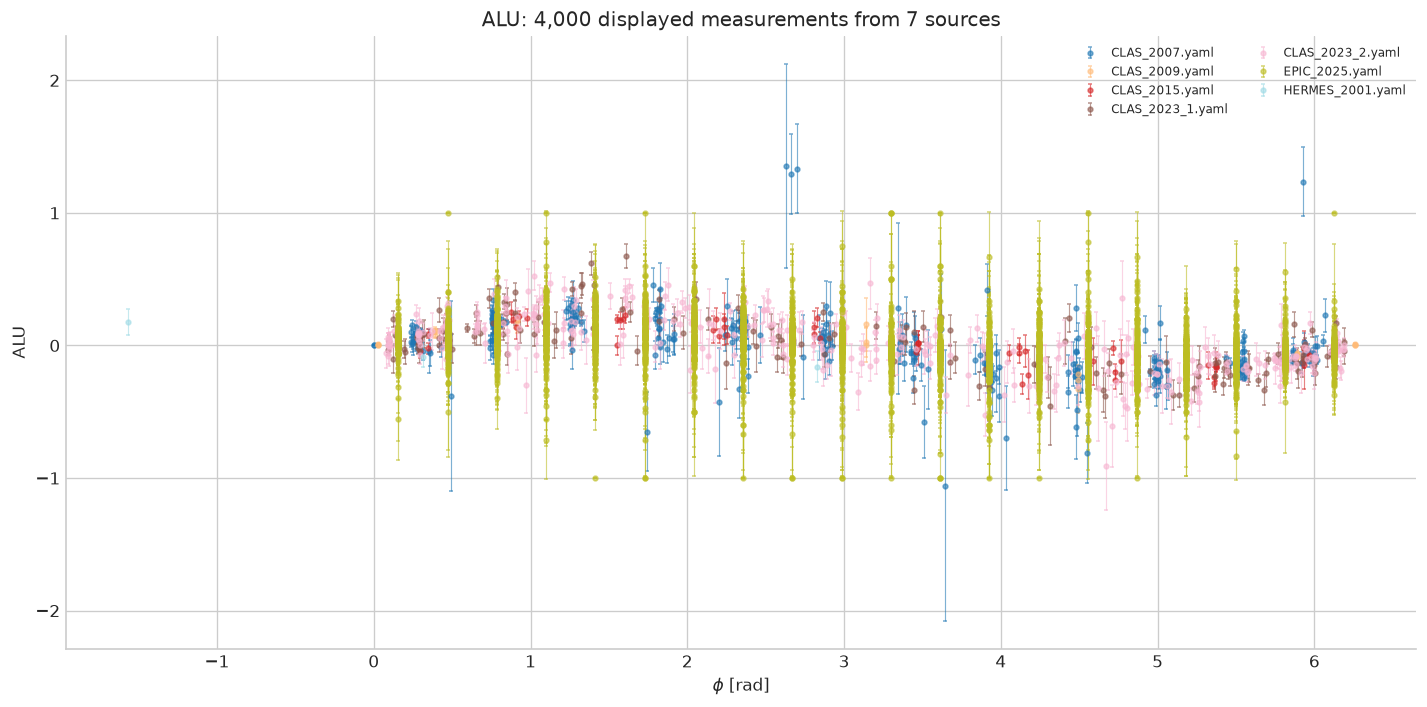

Sources:
  CLAS_2007.yaml: 238 rows | normalization uncertainty: [0.035]
  CLAS_2009.yaml: 21 rows | normalization uncertainty: [0.03]
  CLAS_2015.yaml: 53 rows
  CLAS_2023_1.yaml: 168 rows
  CLAS_2023_2.yaml: 321 rows
  EPIC_2025.yaml: 3,196 rows
  HERMES_2001.yaml: 3 rows


In [8]:
OBSERVABLE = "ALU"
X_AXIS = "auto"  # auto, phi_rad, minus_t, xB, Q2, W, or nu
COLLABORATIONS = None  # Example: {"CLAS", "HERMES"}
MAX_POINTS = 4000

def plot_observable(observable, x_axis="auto", collaborations=None, max_points=4000):
    selected = [row for row in MEASUREMENTS if row["observable"] == observable]
    if collaborations:
        selected = [row for row in selected if row["collaboration"] in collaborations]
    if not selected:
        raise ValueError(f"No rows for {observable!r}; choose from {sorted(observable_counts)}")
    if x_axis == "auto":
        x_axis = next(key for key in ("phi_rad", "minus_t", "xB", "Q2", "W", "nu")
                      if any(math.isfinite(row[key]) for row in selected))
    selected = [row for row in selected if math.isfinite(row[x_axis]) and math.isfinite(row["value"])]
    if len(selected) > max_points:
        indices = np.linspace(0, len(selected) - 1, max_points, dtype=int)
        selected = [selected[index] for index in indices]
    groups = defaultdict(list)
    for row in selected:
        groups[row["source"]].append(row)
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = plt.cm.tab20(np.linspace(0, 1, max(1, len(groups))))
    for color, (source, rows) in zip(colors, sorted(groups.items())):
        rows.sort(key=lambda row: row[x_axis])
        x = np.array([row[x_axis] for row in rows])
        y = np.array([row["value"] for row in rows])
        stat = np.array([row["stat_unc"] for row in rows])
        syst = np.array([row["sys_unc"] for row in rows])
        stat = np.where(np.isfinite(stat), stat, 0.0)
        syst = np.where(np.isfinite(syst), syst, 0.0)
        ax.errorbar(x, y, yerr=np.hypot(stat, syst), fmt="o", ms=2.8, lw=0.7,
                    capsize=1, alpha=0.58, color=color, label=source)
    units = sorted({row["unit"] for row in selected})
    y_label = observable + (f" [{units[0]}]" if len(units) == 1 and units[0] != "none" else "")
    ax.set(xlabel=KINEMATIC_LABELS[x_axis], ylabel=y_label,
           title=f"{observable}: {len(selected):,} displayed measurements from {len(groups)} sources")
    if len(groups) <= 16:
        ax.legend(fontsize=7, ncol=2, frameon=False)
    plt.tight_layout()
    plt.show()
    print("Sources:")
    for source, rows in sorted(groups.items()):
        norm = sorted({row["norm_unc"] for row in rows if math.isfinite(row["norm_unc"])})
        suffix = f" | normalization uncertainty: {norm}" if norm else ""
        print(f"  {source}: {len(rows):,} rows{suffix}")

plot_observable(OBSERVABLE, X_AXIS, COLLABORATIONS, MAX_POINTS)

## Requested observable comparisons

Each row is shown twice: all available DVCS sources, then the same observable after excluding records tagged `pseudodata: true` or `data_type: LATTICE_QCD`. GPDdatabase currently has no lattice-QCD rows carrying these DVCS observables.

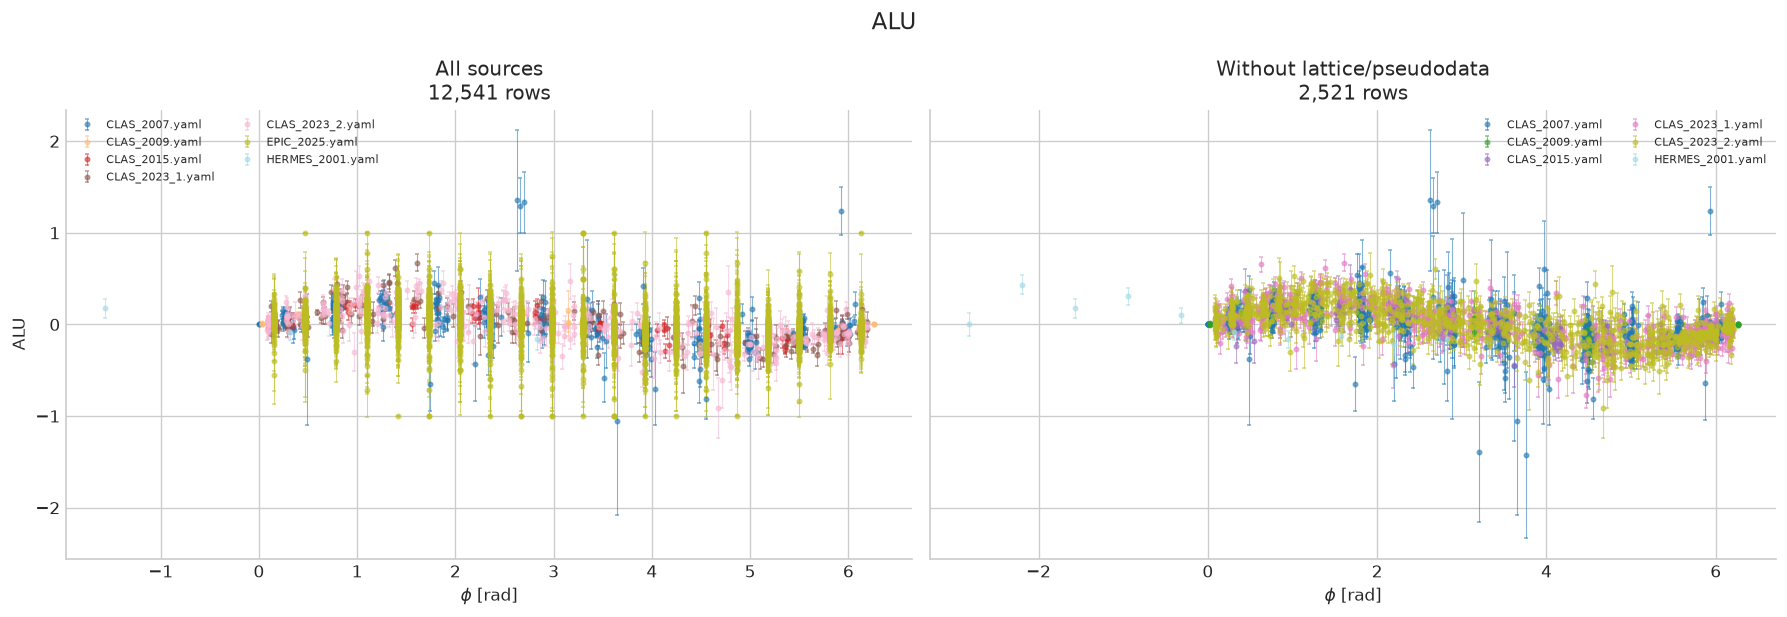

ALU: all=12,541, without lattice/pseudodata=2,521


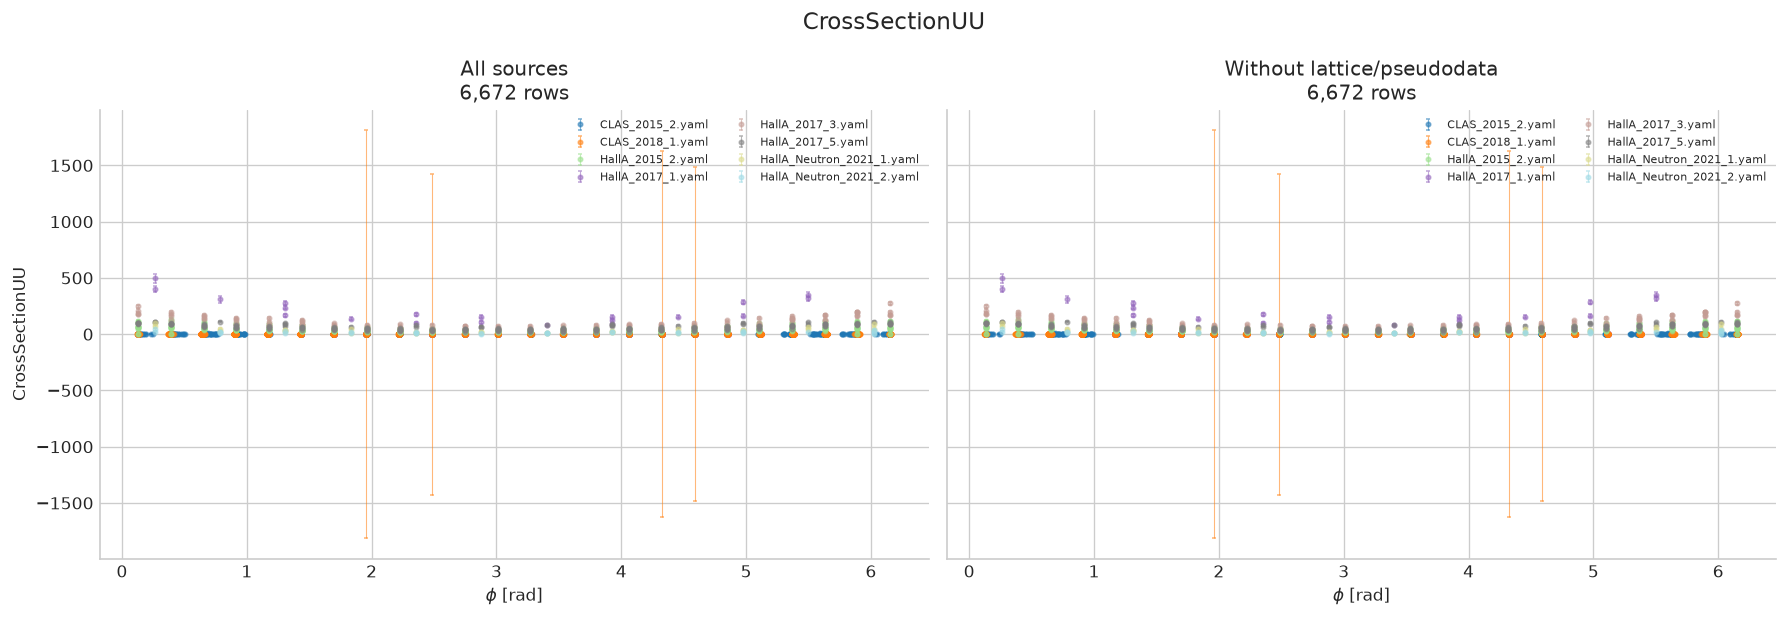

CrossSectionUU: all=6,672, without lattice/pseudodata=6,672


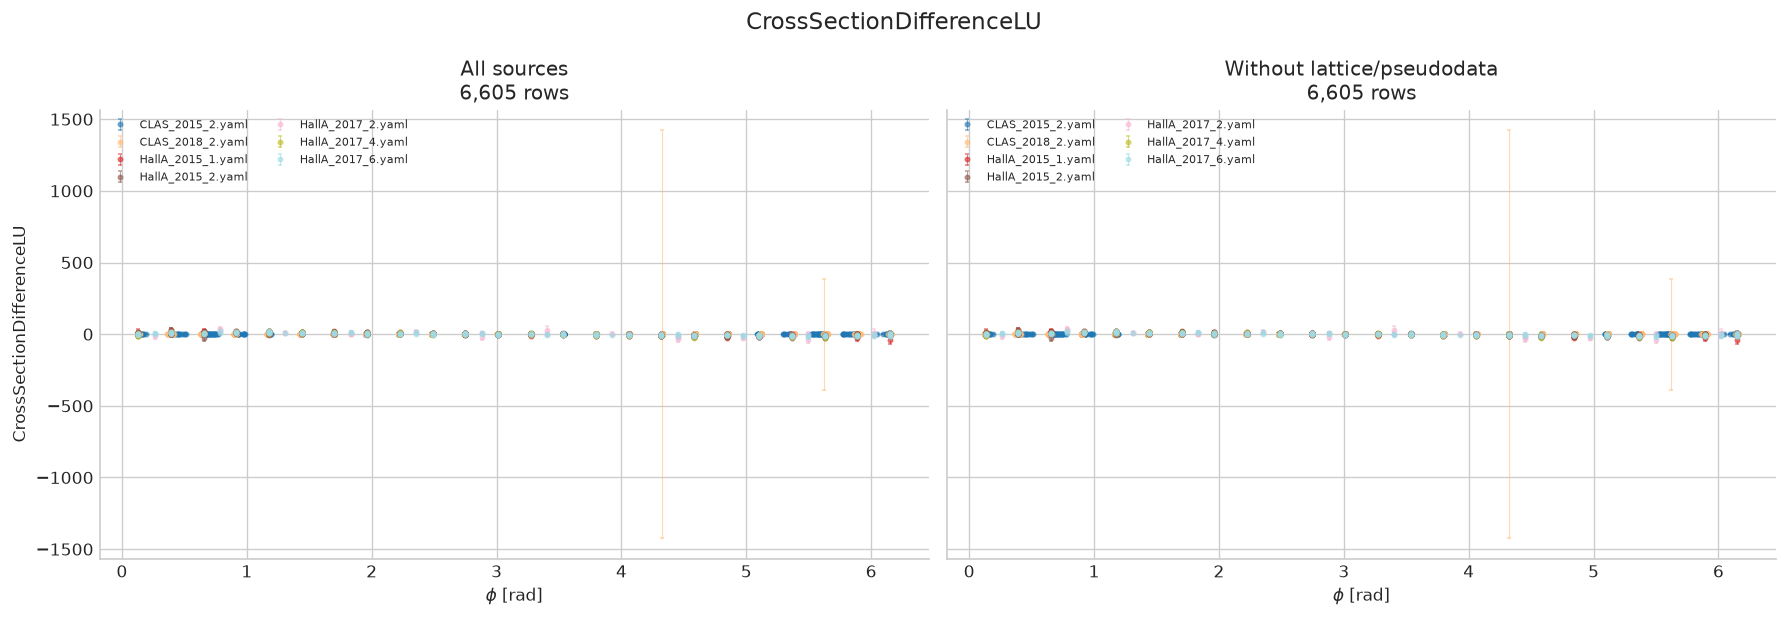

CrossSectionDifferenceLU: all=6,605, without lattice/pseudodata=6,605


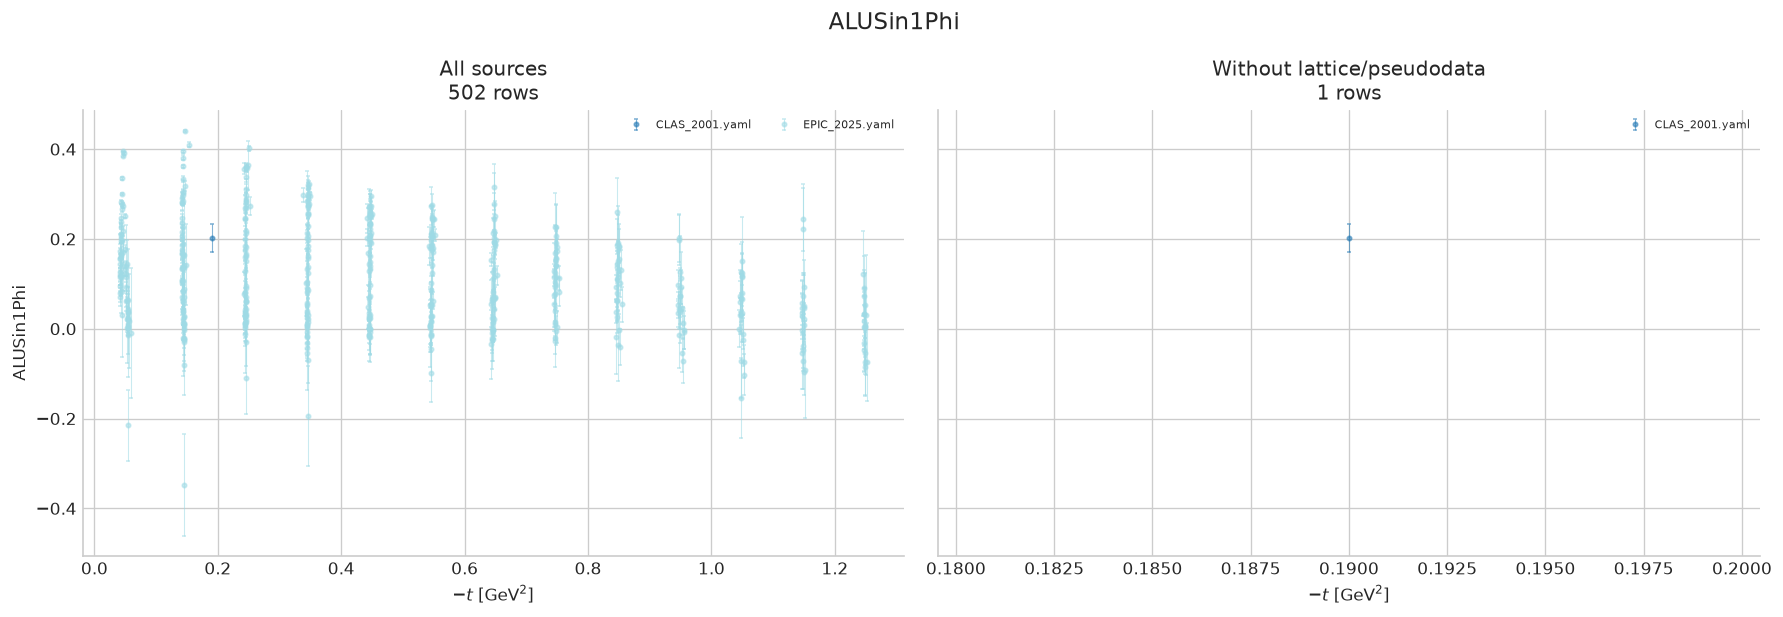

ALUSin1Phi: all=502, without lattice/pseudodata=1


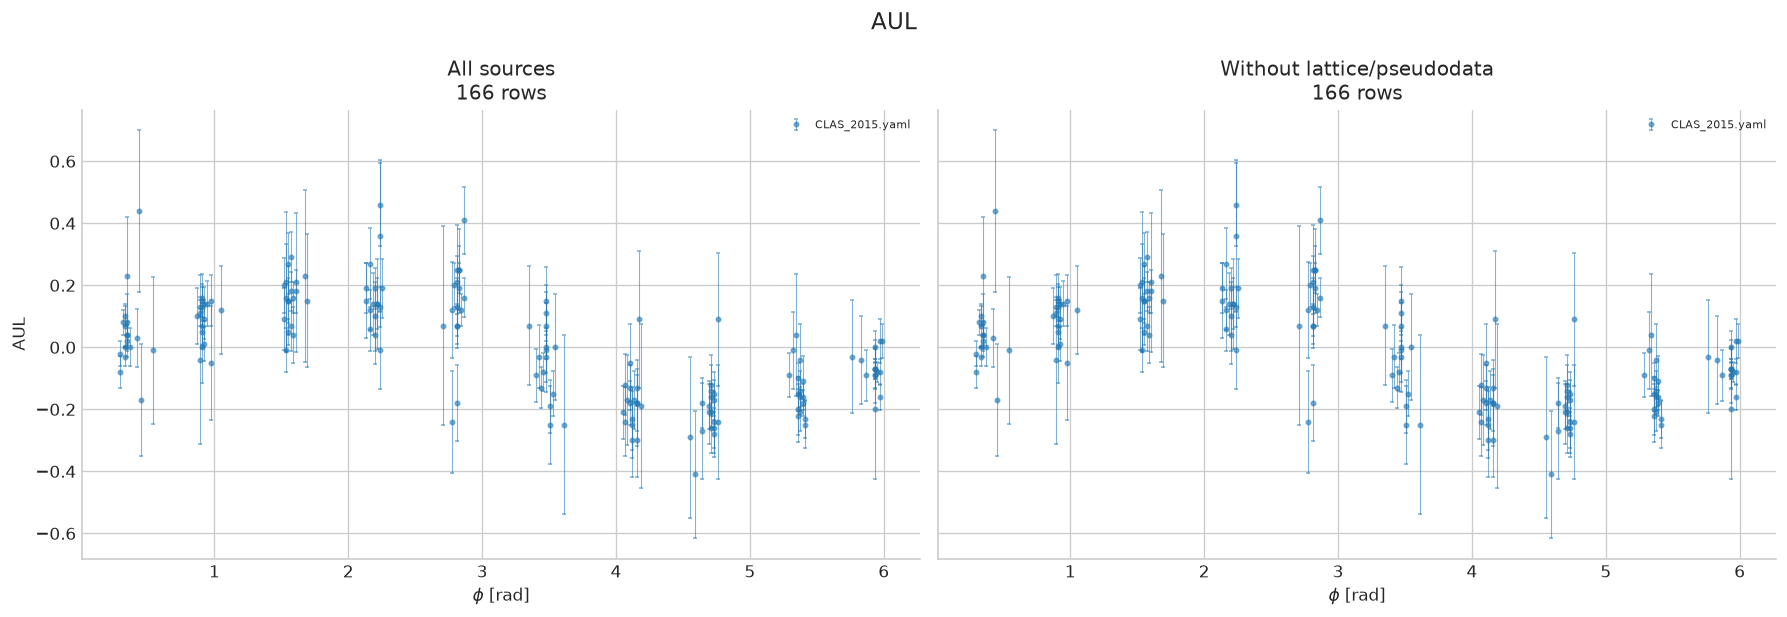

AUL: all=166, without lattice/pseudodata=166


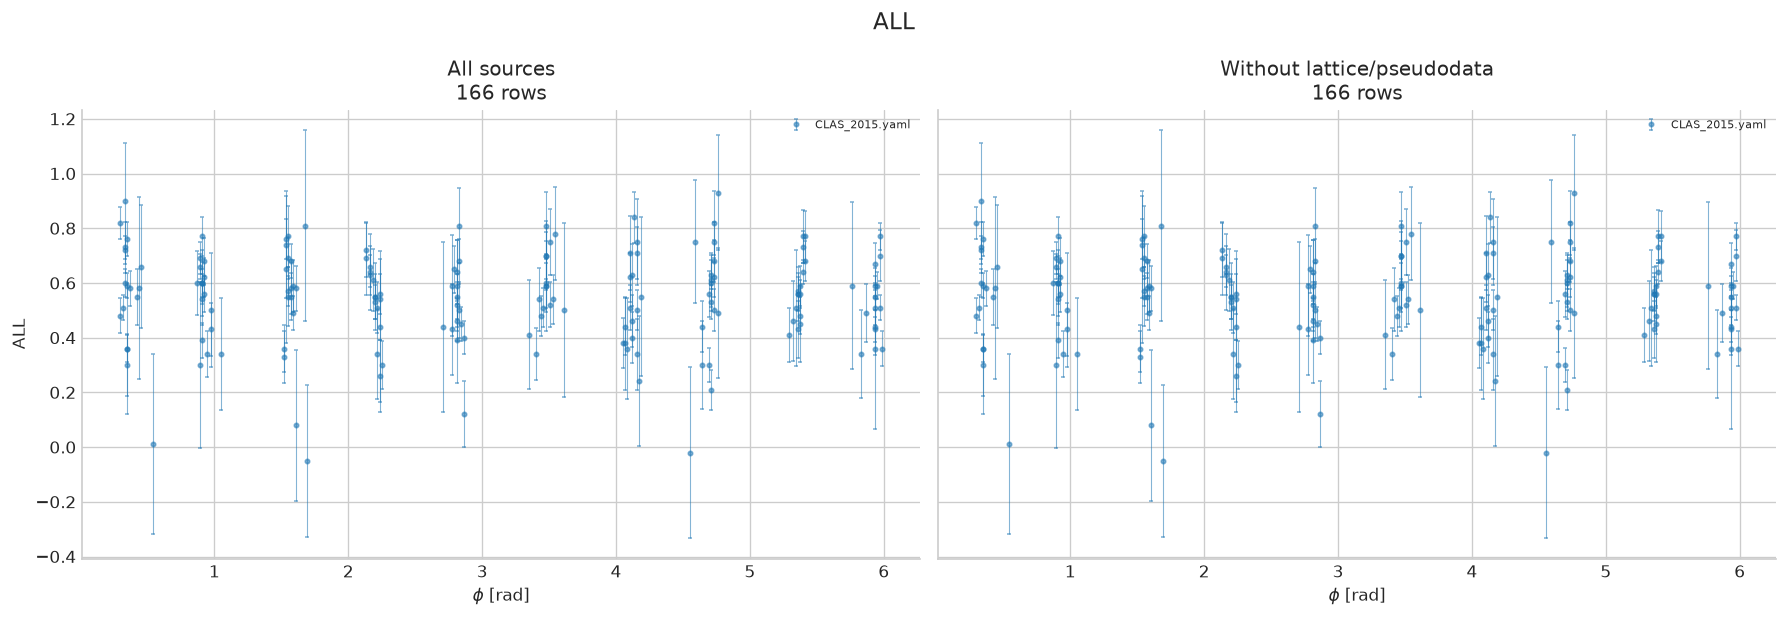

ALL: all=166, without lattice/pseudodata=166


In [9]:
REQUESTED_OBSERVABLES = (
    "ALU", "CrossSectionUU", "CrossSectionDifferenceLU",
    "ALUSin1Phi", "AUL", "ALL",
)

def draw_observable(axis, rows, x_axis, title, max_points=4000):
    total = len(rows)
    rows = [row for row in rows if math.isfinite(row[x_axis]) and math.isfinite(row["value"])]
    if len(rows) > max_points:
        indices = np.linspace(0, len(rows) - 1, max_points, dtype=int)
        rows = [rows[index] for index in indices]
    groups = defaultdict(list)
    for row in rows:
        groups[row["source"]].append(row)
    colors = plt.cm.tab20(np.linspace(0, 1, max(1, len(groups))))
    for color, (source, group) in zip(colors, sorted(groups.items())):
        group.sort(key=lambda row: row[x_axis])
        x = np.array([row[x_axis] for row in group])
        y = np.array([row["value"] for row in group])
        stat = np.nan_to_num([row["stat_unc"] for row in group], nan=0.0)
        syst = np.nan_to_num([row["sys_unc"] for row in group], nan=0.0)
        axis.errorbar(x, y, yerr=np.hypot(stat, syst), fmt="o", ms=2.6, lw=0.65,
                      capsize=1, alpha=0.55, color=color, label=source)
    axis.set(xlabel=KINEMATIC_LABELS[x_axis], title=f"{title}\n{total:,} rows")
    if len(groups) <= 12:
        axis.legend(fontsize=6.5, ncol=2, frameon=False)

def plot_observable_pair(observable):
    all_rows = [row for row in MEASUREMENTS if row["observable"] == observable]
    if not all_rows:
        raise ValueError(f"Observable {observable!r} is unavailable")
    x_axis = next(key for key in ("phi_rad", "minus_t", "xB", "Q2", "W", "nu")
                  if any(math.isfinite(row[key]) for row in all_rows))
    experimental = [row for row in all_rows if not row["lattice_or_pseudodata"]]
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), sharey=True)
    draw_observable(axes[0], all_rows, x_axis, "All sources")
    draw_observable(axes[1], experimental, x_axis, "Without lattice/pseudodata")
    units = sorted({row["unit"] for row in all_rows})
    y_label = observable + (f" [{units[0]}]" if len(units) == 1 and units[0] != "none" else "")
    axes[0].set_ylabel(y_label)
    fig.suptitle(observable, fontsize=14)
    plt.tight_layout()
    plt.show()
    print(f"{observable}: all={len(all_rows):,}, without lattice/pseudodata={len(experimental):,}")

for observable in REQUESTED_OBSERVABLES:
    plot_observable_pair(observable)